# This model is trained on (2020/01/01  to  2023/12/30) 48 month data with STATIC MASK

## Masked on geboc (detailed) depth

In [1]:
# Install the required Python library
# !pip install torchviz

# Install the Graphviz system package (Conda is recommended)
# conda install -c conda-forge python-graphviz -y

In [1]:
import torch

# Check if CUDA is available
cuda_available = torch.cuda.is_available()
print(f"Is CUDA available? {cuda_available}")

# If it is available, check how many GPUs are detected
if cuda_available:
    print(f"Number of GPUs: {torch.cuda.device_count()}")
    print(f"Current GPU Name: {torch.cuda.get_device_name(0)}")

# Check the CUDA version PyTorch was built with

print(f"PyTorch CUDA Version: {torch.version.cuda}")

Is CUDA available? True
Number of GPUs: 2
Current GPU Name: NVIDIA GeForce GTX 1080 Ti
PyTorch CUDA Version: 12.4


In [1]:
# =============================================================================
# MASTER CONFIGURATION CELL
# =============================================================================
import torch
import os

# --- Core Parameters ---
# Change this value to 24, 36, 72, etc., to test different models
version = "v4"
LOOKBACK_HOURS = 48
# Forecast period for training (predicting next 3 hours)
FORECAST_HORIZON_HOURS = 3
# Sliding window parameters for testing
TOTAL_FORECAST_HOURS = 30  # Total hours to predict in sliding window
CORRECTION_WINDOW = 2  # Next 2 hours used for error normalization

# --- File Paths ---
# MODIFICATION: Updated to the new file paths you provided
RAW_DATA_PATH = r'/home/aidl/Wave-Prediction/dAtA/cmems_mod_ibi_wav_my_0.027deg_PT1H-i_multi-vars_11.00W-8.53W_38.50N-40.47N_2020-01-01-2023-12-30.nc'
STATIC_DATA_PATH = r'/home/aidl/Wave-Prediction/dAtA/cmems_GEBCO_resampled1.nc'

# MODIFICATION: File paths are now dynamic to keep experiments separate
BASE_DIR = r'/home/aidl/babe_prediction'
PROCESSED_DATA_DIR = os.path.join(BASE_DIR, f'processed_data_lookback_{LOOKBACK_HOURS}_static_multivar')
# This path is now used by the ModelCheckpoint callback in Lightning
MODEL_SAVE_DIR = '/home/aidl/Wave-Prediction/models/'
MODEL_SAVE_PATH = os.path.join(MODEL_SAVE_DIR, f'convlstm_lookback_{LOOKBACK_HOURS}_forecast_{FORECAST_HORIZON_HOURS}_{version}.pth')


# --- Feature Engineering ---
# These are the TIME-VARYING features
VARS_TO_USE = ['VCMX','VHM0_SW1', 'VSDmag', 'VHM0_WW', 'VTM01_WW', 'VTM02', 'VTM01_SW1', 'VTM10']
# MODIFICATION: Now predicting ALL variables (multivariate output)
TARGET_VARS = VARS_TO_USE  # Predict all 7 variables
NUM_OUTPUT_CHANNELS = len(TARGET_VARS)  # Output channels = 7 variables
# MODIFICATION: Total input channels = 7 time-varying + 2 static (depth, mask)
INPUT_CHANNELS = len(VARS_TO_USE) + 2

# --- Training Hyperparameters ---
LEARNING_RATE = 1e-5
BATCH_SIZE = 8
EPOCHS = 50
# MODIFICATION: Early stopping patience is now a configurable parameter
EARLY_STOPPING_PATIENCE = 5

# --- System Configuration ---
NUM_WORKERS = 4  # Set to 0 if you encounter multiprocessing issues, 4+ for speed
# device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# --- Print a summary of the current configuration ---
print("--- Configuration Summary ---")
print(f"Project version: {version}")
print(f"Lookback Period: {LOOKBACK_HOURS} hours")
print(f"Training Forecast Horizon: {FORECAST_HORIZON_HOURS} hours")
print(f"Testing Total Forecast (Sliding Window): {TOTAL_FORECAST_HOURS} hours")
print(f"Correction Window: {CORRECTION_WINDOW} hours")
print(f"Input Channels: {INPUT_CHANNELS} ({len(VARS_TO_USE)} time-varying + 2 static)")
print(f"Output Channels (Target Variables): {NUM_OUTPUT_CHANNELS} (multivariate: {', '.join(TARGET_VARS)})")
print(f"Processed Data Path: {PROCESSED_DATA_DIR}")
print(f"Model Save Directory: {MODEL_SAVE_DIR}")
# print(f"Using Device: {device}")
print("---------------------------")

--- Configuration Summary ---
Project version: v4
Lookback Period: 48 hours
Training Forecast Horizon: 3 hours
Testing Total Forecast (Sliding Window): 30 hours
Correction Window: 2 hours
Input Channels: 10 (8 time-varying + 2 static)
Output Channels (Target Variables): 8 (multivariate: VCMX, VHM0_SW1, VSDmag, VHM0_WW, VTM01_WW, VTM02, VTM01_SW1, VTM10)
Processed Data Path: /home/aidl/babe_prediction/processed_data_lookback_48_static_multivar
Model Save Directory: /home/aidl/Wave-Prediction/models/
---------------------------


In [8]:
ds_raw = xr.open_dataset(RAW_DATA_PATH)
# ['VHM0_SW1', 'VSDmag', 'VHM0_WW', 'VTM01_WW', 'VTM02', 'VTM01_SW1', 'VTM10']
ds_raw.data_vars

Data variables:
    VHM0_WW    (time, latitude, longitude) float64 2GB ...
    VCMX       (time, latitude, longitude) float64 2GB ...
    VHM0       (time, latitude, longitude) float64 2GB ...
    VHM0_SW1   (time, latitude, longitude) float64 2GB ...
    VHM0_SW2   (time, latitude, longitude) float64 2GB ...
    VMDR       (time, latitude, longitude) float64 2GB ...
    VMDR_SW1   (time, latitude, longitude) float64 2GB ...
    VMDR_SW2   (time, latitude, longitude) float64 2GB ...
    VMDR_WW    (time, latitude, longitude) float64 2GB ...
    VMXL       (time, latitude, longitude) float64 2GB ...
    VPED       (time, latitude, longitude) float64 2GB ...
    VSDX       (time, latitude, longitude) float64 2GB ...
    VSDY       (time, latitude, longitude) float64 2GB ...
    VTM01_SW1  (time, latitude, longitude) float64 2GB ...
    VTM01_SW2  (time, latitude, longitude) float64 2GB ...
    VTM01_WW   (time, latitude, longitude) float64 2GB ...
    VTM02      (time, latitude, longitud

# STEP 1: PRE-PROCESSING SCRIPT (with Static Features)

In [3]:
# =============================================================================
# =============================================================================
import os
import pickle
import xarray as xr
import numpy as np
import torch
from sklearn.preprocessing import MinMaxScaler
from tqdm.auto import tqdm
import warnings
import shutil

warnings.filterwarnings('ignore')

if os.path.exists(PROCESSED_DATA_DIR):
    print(f"Removing old processed data directory: {PROCESSED_DATA_DIR}")
    shutil.rmtree(PROCESSED_DATA_DIR)

print("\n--- Starting Full Pre-processing Workflow ---")

# Step 1: Load and Clean Data
print("\n[Step 1/5] Loading and cleaning all data...")
ds_raw = xr.open_dataset(RAW_DATA_PATH)
ds_raw['VSDmag'] = np.sqrt(ds_raw['VSDX']**2 + ds_raw['VSDY']**2)
ds_clean = ds_raw[VARS_TO_USE].astype(np.float32).fillna(0)
print("✅ Time-varying data loaded and cleaned.")

ds_static = xr.open_dataset(STATIC_DATA_PATH)
ocean_depth = ds_static['deptho'].values.astype(np.float32)
ocean_mask = ds_static['mask'].values.astype(np.float32)
print("✅ Static data loaded and cleaned from new GEBCO file.")

# Step 2: Define Data Splits
print("\n[Step 2/5] Splitting data into train, validation, and test sets...")
ds_train = ds_clean.sel(time=slice('2020-01-01', '2022-12-31'))
ds_val = ds_clean.sel(time=slice('2023-01-01', '2023-06-30'))
ds_test = ds_clean.sel(time=slice('2023-07-01', '2023-12-30'))
ds_splits = {'train': ds_train, 'val': ds_val, 'test': ds_test}
print(f"Train split: {len(ds_train.time)} time steps")
print(f"Validation split: {len(ds_val.time)} time steps")
print(f"Test split: {len(ds_test.time)} time steps")

# Step 3: Create and Save Scalers
print("\n[Step 3/5] Fitting scalers on TRAINING data only...")
scalers = {}
for var in tqdm(VARS_TO_USE, desc="Fitting Time-Varying Scalers"):
    data_to_fit = ds_train[var].values.reshape(-1, 1)
    scaler = MinMaxScaler()
    scaler.fit(data_to_fit)
    scalers[var] = scaler

print("Fitting static feature scalers...")
depth_scaler = MinMaxScaler()
depth_scaler.fit(ocean_depth.reshape(-1, 1))
scalers['ocean_depth'] = depth_scaler

os.makedirs(PROCESSED_DATA_DIR, exist_ok=True)
scaler_path = os.path.join(PROCESSED_DATA_DIR, 'scalers_mask.pkl')
with open(scaler_path, 'wb') as f:
    pickle.dump(scalers, f)
print(f"✅ All scalers fitted and saved to '{scaler_path}'")

# Step 4: Scale Static Features
print("\n[Step 4/5] Scaling static features...")
scaled_depth = scalers['ocean_depth'].transform(ocean_depth.reshape(-1, 1)).reshape(ocean_depth.shape)
scaled_depth_ch = np.expand_dims(scaled_depth, axis=0)
ocean_mask_ch = np.expand_dims(ocean_mask, axis=0)
static_features_np = np.concatenate([scaled_depth_ch, ocean_mask_ch], axis=0)
print("✅ Static features scaled.")

# Step 5: Process and Save Samples
print("\n[Step 5/5] Generating and saving individual samples...")
total_window_size = LOOKBACK_HOURS + FORECAST_HORIZON_HOURS

for split_name, ds_split in ds_splits.items():
    print(f"\n--- Processing '{split_name}' split ---")
    split_dir = os.path.join(PROCESSED_DATA_DIR, split_name)
    os.makedirs(split_dir, exist_ok=True)
    
    num_sequences = len(ds_split['time']) - total_window_size
    for i in tqdm(range(num_sequences), desc=f"Saving {split_name} samples"):
        window_slice = ds_split.isel(time=slice(i, i + total_window_size))
        
        scaled_window_vars = []
        for var in VARS_TO_USE:
            data = window_slice[var].values
            scaled_data = scalers[var].transform(data.reshape(-1, 1)).reshape(data.shape)
            scaled_window_vars.append(scaled_data)
        
        scaled_window_tensor = np.stack(scaled_window_vars, axis=1)

        X_tv_np = scaled_window_tensor[:LOOKBACK_HOURS, :, :, :]
        # MODIFICATION: Extract ALL variables for target (multivariate output)
        # Shape: (FORECAST_HORIZON_HOURS, NUM_OUTPUT_CHANNELS, H, W)
        y_np = scaled_window_tensor[LOOKBACK_HOURS:, :, :, :]

        static_features_tiled = np.tile(static_features_np, (LOOKBACK_HOURS, 1, 1, 1))
        X_final_np = np.concatenate([X_tv_np, static_features_tiled], axis=1)

        X = torch.from_numpy(X_final_np.astype(np.float32))
        y = torch.from_numpy(y_np.astype(np.float32))
        
        sample_path = os.path.join(split_dir, f'sample_{i:06d}.pt')
        torch.save((X, y), sample_path)

print(f"\n\n✅ Pre-processing complete! Data is ready at: '{PROCESSED_DATA_DIR}'")

Removing old processed data directory: /home/aidl/babe_prediction/processed_data_lookback_48_static_multivar

--- Starting Full Pre-processing Workflow ---

[Step 1/5] Loading and cleaning all data...
✅ Time-varying data loaded and cleaned.
✅ Static data loaded and cleaned from new GEBCO file.

[Step 2/5] Splitting data into train, validation, and test sets...
Train split: 26304 time steps
Validation split: 4344 time steps
Test split: 4392 time steps

[Step 3/5] Fitting scalers on TRAINING data only...


Fitting Time-Varying Scalers:   0%|          | 0/8 [00:00<?, ?it/s]

Fitting static feature scalers...
✅ All scalers fitted and saved to '/home/aidl/babe_prediction/processed_data_lookback_48_static_multivar/scalers_mask.pkl'

[Step 4/5] Scaling static features...
✅ Static features scaled.

[Step 5/5] Generating and saving individual samples...

--- Processing 'train' split ---


Saving train samples:   0%|          | 0/26253 [00:00<?, ?it/s]


--- Processing 'val' split ---


Saving val samples:   0%|          | 0/4293 [00:00<?, ?it/s]


--- Processing 'test' split ---


Saving test samples:   0%|          | 0/4341 [00:00<?, ?it/s]



✅ Pre-processing complete! Data is ready at: '/home/aidl/babe_prediction/processed_data_lookback_48_static_multivar'


# STEP 2: TRAINING SCRIPT

In [2]:
# =============================================================================
# STEP 2.1: DEFINE THE LIGHTNING DATAMODULE
# =============================================================================
import pytorch_lightning as pl
import os
import glob
from torch.utils.data import Dataset, DataLoader

# Your existing Dataset class (no changes needed)
class PreprocessedWaveDataset(Dataset):
    def __init__(self, split_dir):
        self.file_paths = sorted(glob.glob(os.path.join(split_dir, '*.pt')))
    def __len__(self):
        return len(self.file_paths)
    def __getitem__(self, idx):
        return torch.load(self.file_paths[idx])

# New DataModule to handle DataLoaders
class WaveDataModule(pl.LightningDataModule):
    def __init__(self, data_dir, batch_size, num_workers):
        super().__init__()
        self.data_dir = data_dir
        self.batch_size = batch_size
        self.num_workers = num_workers

    def setup(self, stage=None):
        # Assign train/val datasets for use in dataloaders
        if stage == 'fit' or stage is None:
            self.train_dataset = PreprocessedWaveDataset(os.path.join(self.data_dir, 'train'))
            self.val_dataset = PreprocessedWaveDataset(os.path.join(self.data_dir, 'val'))
            print(f"DataModule setup complete: {len(self.train_dataset)} training samples, {len(self.val_dataset)} validation samples.")

    def train_dataloader(self):
        return DataLoader(
            self.train_dataset,
            batch_size=self.batch_size,
            shuffle=True,
            num_workers=self.num_workers,
            pin_memory=True,
            persistent_workers=False # CHANGED
        )

    def val_dataloader(self):
        return DataLoader(
            self.val_dataset,
            batch_size=self.batch_size,
            shuffle=False,
            num_workers=self.num_workers,
            pin_memory=True,
            persistent_workers=False # CHANGED
        )

In [14]:
# =============================================================================
# STEP 2.2: DEFINE THE LIGHTNINGMODULE (DeepLab-style Encoder + ConvGRU)
# =============================================================================
import torch
import torch.nn as nn
import pytorch_lightning as pl

# --- ConvGRU Cell ---
class ConvGRUCell(nn.Module):
    def __init__(self, input_dim, hidden_dim, kernel_size, bias=True):
        super().__init__()
        self.hidden_dim = hidden_dim
        padding = kernel_size[0] // 2
        self.conv = nn.Conv2d(
            input_dim + hidden_dim,
            3 * hidden_dim,
            kernel_size,
            padding=padding,
            bias=bias
        )

    def forward(self, x, h):
        gates = self.conv(torch.cat([x, h], dim=1))
        r, z, n = torch.split(gates, self.hidden_dim, dim=1)
        r = torch.sigmoid(r)
        z = torch.sigmoid(z)
        n = torch.tanh(r * h + n)
        return (1 - z) * n + z * h

    def init_hidden(self, b, spatial, device):
        h, w = spatial
        return torch.zeros(b, self.hidden_dim, h, w, device=device)


# --- Bidirectional ConvGRU ---
class ConvGRU(nn.Module):
    def __init__(self, input_dim, hidden_dim, kernel_size=(3,3), num_layers=1, bidirectional=True):
        super().__init__()
        self.num_layers = num_layers
        self.bidirectional = bidirectional
        self.hidden_dim = hidden_dim

        self.fwd_cells = nn.ModuleList()
        self.bwd_cells = nn.ModuleList() if bidirectional else None

        for i in range(num_layers):
            in_dim = input_dim if i == 0 else hidden_dim * (2 if bidirectional else 1)
            self.fwd_cells.append(ConvGRUCell(in_dim, hidden_dim, kernel_size))
            if bidirectional:
                self.bwd_cells.append(ConvGRUCell(in_dim, hidden_dim, kernel_size))

    def forward(self, x):
        # x: (B, T, C, H, W)
        B, T, C, H, W = x.shape
        cur_fwd = x

        for i in range(self.num_layers):
            h = self.fwd_cells[i].init_hidden(B, (H, W), x.device)
            fwd_out = []
            for t in range(T):
                h = self.fwd_cells[i](cur_fwd[:, t], h)
                fwd_out.append(h)
            fwd_out = torch.stack(fwd_out, dim=1)  # (B, T, hidden, H, W)

            if self.bidirectional:
                h = self.bwd_cells[i].init_hidden(B, (H, W), x.device)
                bwd_out = []
                for t in range(T - 1, -1, -1):
                    h = self.bwd_cells[i](cur_fwd[:, t], h)
                    bwd_out.append(h)
                bwd_out.reverse()
                bwd_out = torch.stack(bwd_out, dim=1)
                cur_fwd = torch.cat([fwd_out, bwd_out], dim=2)  # (B, T, hidden*2, H, W)
            else:
                cur_fwd = fwd_out

        return cur_fwd  # (B, T, hidden*2, H, W)


# --- Lightweight DeepLab-style Encoder (Mini-ASPP, no ResNet backbone) ---
class LightDeepLabEncoder(nn.Module):
    def __init__(self, input_channels, output_channels=64):
        super().__init__()
        self.stem = nn.Sequential(
            nn.Conv2d(input_channels, 32, 3, padding=1),
            nn.BatchNorm2d(32), nn.ReLU(),
            nn.Conv2d(32, 64, 3, padding=1),
            nn.BatchNorm2d(64), nn.ReLU(),
            nn.Conv2d(64, 128, 3, padding=1),
            nn.BatchNorm2d(128), nn.ReLU(),
        )
        # Mini-ASPP: 4 parallel dilated convs + global context
        self.aspp1 = nn.Conv2d(128, 32, 1)
        self.aspp2 = nn.Conv2d(128, 32, 3, padding=6,  dilation=6)
        self.aspp3 = nn.Conv2d(128, 16, 3, padding=12, dilation=12)
        # self.aspp4 = nn.Conv2d(128, 32, 3, padding=18, dilation=18)
        self.gap    = nn.AdaptiveAvgPool2d(1)
        self.gap_proj = nn.Conv2d(128, 16, 1)

        self.project = nn.Sequential(
            nn.Conv2d(96, output_channels, 1),
            nn.BatchNorm2d(output_channels),
            nn.ReLU()
        )

    def forward(self, x):
        f = self.stem(x)
        a1 = self.aspp1(f)
        a2 = self.aspp2(f)
        a3 = self.aspp3(f)
        # a4 = self.aspp4(f)
        gap = self.gap_proj(self.gap(f))                          # (B, 16, 1, 1)
        gap = gap.expand(-1, -1, f.shape[2], f.shape[3]) 
        return self.project(torch.cat([a1, a2, a3, gap], dim=1))  # (B, 64, H, W)


# --- Full Model ---
class DeepLabConvGRUNet(nn.Module):
    def __init__(self, input_dim, forecast_horizon, num_output_channels,
                 encoder_out_channels=64, hidden_dims=[32, 16], kernel_size=(3, 3)):
        super().__init__()
        self.forecast_horizon = forecast_horizon
        self.num_output_channels = num_output_channels

        self.encoder = LightDeepLabEncoder(input_dim, encoder_out_channels)

        self.gru1 = ConvGRU(encoder_out_channels, hidden_dims[0], kernel_size, num_layers=1, bidirectional=True)
        self.gru2 = ConvGRU(hidden_dims[0] * 2,   hidden_dims[1], kernel_size, num_layers=1, bidirectional=True)

        self.output_conv = nn.Conv2d(
            hidden_dims[1] * 2,
            forecast_horizon * num_output_channels,
            kernel_size=1
        )

    def forward(self, x_seq):
        # x_seq: (B, T, C, H, W)
        B, T, C, H, W = x_seq.shape

        # Encode all timesteps at once — no Python loop, uses batch dim trick
        x_flat = x_seq.view(B * T, C, H, W)
        enc = self.encoder(x_flat)                          # (B*T, 64, H, W)
        _, C_enc, H_enc, W_enc = enc.shape
        enc = enc.view(B, T, C_enc, H_enc, W_enc)          # (B, T, 64, H, W)

        # ConvGRU temporal processing — spatial maps never flattened
        l1 = self.gru1(enc)                                 # (B, T, 64, H, W)
        l2 = self.gru2(l1)                                  # (B, T, 32, H, W)

        # Take last timestep and decode
        last = l2[:, -1]                                    # (B, 32, H, W)
        out  = self.output_conv(last)                       # (B, F*C_out, H, W)

        # Upsample to original resolution if spatial dims changed
        if (H_enc, W_enc) != (H, W):
            out = nn.functional.interpolate(out, size=(H, W), mode='bilinear', align_corners=False)

        return out.view(B, self.forecast_horizon, self.num_output_channels, H, W)


# --- LightningModule (same interface as before, drop-in replacement) ---
class WavePredLightningModule(pl.LightningModule):
    def __init__(self, input_dim, forecast_horizon, num_output_channels, lr):
        super().__init__()
        self.save_hyperparameters()
        self.model = DeepLabConvGRUNet(
            input_dim=input_dim,
            forecast_horizon=forecast_horizon,
            num_output_channels=num_output_channels,
            encoder_out_channels=64,
            hidden_dims=[32, 16]
        )
        self.loss_fn = nn.MSELoss()
        self.history = {'train_loss': [], 'val_loss': []}

    def forward(self, x):
        return self.model(x)

    def training_step(self, batch, batch_idx):
        x, y = batch
        loss = self.loss_fn(self(x), y)
        self.log('train_loss', loss, on_step=True, on_epoch=True, prog_bar=True, logger=True, sync_dist=True)
        return loss

    def validation_step(self, batch, batch_idx):
        x, y = batch
        loss = self.loss_fn(self(x), y)
        self.log('val_loss', loss, on_epoch=True, prog_bar=True, logger=True, sync_dist=True)
        return loss

    def configure_optimizers(self):
        return torch.optim.Adam(self.parameters(), lr=self.hparams.lr)

    def on_validation_epoch_end(self):
        if self.trainer.global_rank == 0:
            metrics = self.trainer.callback_metrics
            if 'val_loss' in metrics:
                self.history['val_loss'].append(metrics['val_loss'].item())
            if 'train_loss_epoch' in metrics:
                self.history['train_loss'].append(metrics['train_loss_epoch'].item())

# OPTIONAL: VISUALIZE THE NEURAL NETWORK ARCHITECTURE

In [ ]:
# =============================================================================
# OPTIONAL: VISUALIZE THE NEURAL NETWORK ARCHITECTURE
# =============================================================================
from torchvision.models.segmentation import deeplabv3_resnet50
import torch

print("--- Generating Neural Network Diagram ---")

# 1. Instantiate your model directly
# We use the DeepLabV3BiGRUNet class defined in your STEP 2.2 cell
model_to_visualize = DeepLabV3BiGRUNet(
    input_dim=INPUT_CHANNELS,
    forecast_horizon=FORECAST_HORIZON_HOURS,
    num_output_channels=NUM_OUTPUT_CHANNELS
)

# 2. Create a sample input tensor with the correct shape
# The shape is (Batch, Sequence Length, Channels, Height, Width).
# IMPORTANT: We use a short sequence length (S=2) for faster visualization.
# Based on your data file, H=73 and W=92.
B, S, C, H, W = 1, 2, INPUT_CHANNELS, 73, 92
sample_input = torch.randn(B, S, C, H, W)

# 3. Perform a forward pass to trace the graph
output = model_to_visualize(sample_input)

print(f"✅ Model instantiated successfully!")
print(f"   Input shape: {sample_input.shape}")
print(f"   Output shape: {output.shape}")
print(f"   Expected output shape: (1, {FORECAST_HORIZON_HOURS}, {NUM_OUTPUT_CHANNELS}, 73, 92)")


ModuleNotFoundError: No module named 'torchviz'

## 6569 min 15 sec

In [15]:
# =============================================================================
# STEP 2.3: CONFIGURE AND RUN THE PYTORCH LIGHTNING TRAINER (MULTI-GPU NOTEBOOK)
# =============================================================================
from pytorch_lightning.callbacks import ModelCheckpoint, EarlyStopping, TQDMProgressBar
import torch
import os

print("--- Starting PyTorch Lightning Training (Multi-GPU DDP Notebook) ---\n")

# 1. Clear any cached memory from previous runs
# torch.cuda.empty_cache()

# 3. Set up DataModule
data_module = WaveDataModule(
    data_dir=PROCESSED_DATA_DIR,
    batch_size=4,
    num_workers=4  # Set to 0 for notebook compatibility with DDP
)

# 4. Set up LightningModule
lightning_model = WavePredLightningModule(
    input_dim=INPUT_CHANNELS,
    forecast_horizon=FORECAST_HORIZON_HOURS,
    num_output_channels=NUM_OUTPUT_CHANNELS,
    lr=LEARNING_RATE
)

# 5. Configure Callbacks
checkpoint_callback = ModelCheckpoint(
    dirpath=MODEL_SAVE_DIR,
    filename=f'{version}_deeplabconvgru-lookback{LOOKBACK_HOURS}-multivar-{{epoch:02d}}-{{val_loss:.4f}}',
    save_top_k=1,
    verbose=True,
    monitor='val_loss',
    mode='min'
)

early_stopping_callback = EarlyStopping(
    monitor='val_loss',
    patience=EARLY_STOPPING_PATIENCE,
    verbose=True,
    mode='min'
)

# Progress bar callback to create a single, clean progress bar
progress_bar_callback = TQDMProgressBar(refresh_rate=10)

# 6. Configure the Trainer - Using ddp_notebook strategy for multi-GPU in Jupyter
trainer = pl.Trainer(
    accelerator='gpu',
    devices=[0, 1],  # Use both GPUs
    strategy='ddp_notebook',  # DDP strategy optimized for Jupyter notebooks
    precision='16-mixed',
    accumulate_grad_batches=2,
    max_epochs=EPOCHS,
    callbacks=[checkpoint_callback, early_stopping_callback, progress_bar_callback],
    log_every_n_steps=10,
    sync_batchnorm=True,  # Synchronize batch norm across GPUs
    enable_progress_bar=True
)

# 7. Start Training (fresh start with multivariate model)
print(f"Starting training for {EPOCHS} epochs on 2 GPUs (ddp_notebook strategy)...\n")
trainer.fit(lightning_model, data_module)

print(f"\n✅ Training finished. Best model saved at: {checkpoint_callback.best_model_path}")
best_model_path = checkpoint_callback.best_model_path

Using 16bit Automatic Mixed Precision (AMP)
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores


--- Starting PyTorch Lightning Training (Multi-GPU DDP Notebook) ---

Starting training for 50 epochs on 2 GPUs (ddp_notebook strategy)...



Initializing distributed: GLOBAL_RANK: 0, MEMBER: 1/2
Initializing distributed: GLOBAL_RANK: 1, MEMBER: 2/2
----------------------------------------------------------------------------------------------------
distributed_backend=nccl
All distributed processes registered. Starting with 2 processes
----------------------------------------------------------------------------------------------------



DataModule setup complete: 26253 training samples, 4293 validation samples.
DataModule setup complete: 26253 training samples, 4293 validation samples.


/home/aidl/anaconda3/envs/notebook-env/lib/python3.10/site-packages/pytorch_lightning/callbacks/model_checkpoint.py:881: Checkpoint directory /home/aidl/Wave-Prediction/models exists and is not empty.
LOCAL_RANK: 1 - CUDA_VISIBLE_DEVICES: [0,1]
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1]
/home/aidl/anaconda3/envs/notebook-env/lib/python3.10/site-packages/pytorch_lightning/utilities/model_summary/model_summary.py:242: Precision 16-mixed is not supported by the model summary.  Estimated model size in MB will not be accurate. Using 32 bits instead.


...

Epoch 48, global step 80409: 'val_loss' was not in top 1
/tmp/ipykernel_374656/1200474575.py:16: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  return torch.load(self.file_pa

Validation: |          | 0/? [00:00<?, ?it/s]

Epoch 49, global step 82050: 'val_loss' was not in top 1
`Trainer.fit` stopped: `max_epochs=50` reached.



✅ Training finished. Best model saved at: /home/aidl/Wave-Prediction/models/v4_deeplabconvgru-lookback48-multivar-epoch=45-val_loss=0.0005.ckpt


/home/aidl/anaconda3/envs/notebook-env/lib/python3.10/site-packages/lightning_fabric/utilities/cloud_io.py:73: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.


In [16]:
lightning_model.history

{'train_loss': [], 'val_loss': []}

In [2]:
from tensorboard.backend.event_processing import event_accumulator
f1 = "/home/aidl/Wave-Prediction/"
f2 = "V3/lightning_logs/version_36/events.out.tfevents.1773323926.aidl-X11DAi-N"

event_file = f1+f2
ea = event_accumulator.EventAccumulator(event_file)
ea.Reload()

print(ea.Tags())  # see available metrics

train_events = ea.Scalars('train_loss_epoch')
val_events = ea.Scalars('val_loss')

train_loss = [x.value for x in train_events]
val_loss   = [x.value for x in val_events]

print("Train Loss History:", len(train_loss))
print("Validation Loss History:", len(val_loss))

full_history = {
    'train_loss': train_loss,
    'val_loss': val_loss
}
print(train_loss[-1], val_loss[-1])

{'images': [], 'audio': [], 'histograms': [], 'scalars': ['hp_metric', 'train_loss_step', 'epoch', 'val_loss', 'train_loss_epoch'], 'distributions': [], 'tensors': [], 'graph': False, 'meta_graph': False, 'run_metadata': []}
Train Loss History: 50
Validation Loss History: 50
0.0005557332187891006 0.0005114713567309082


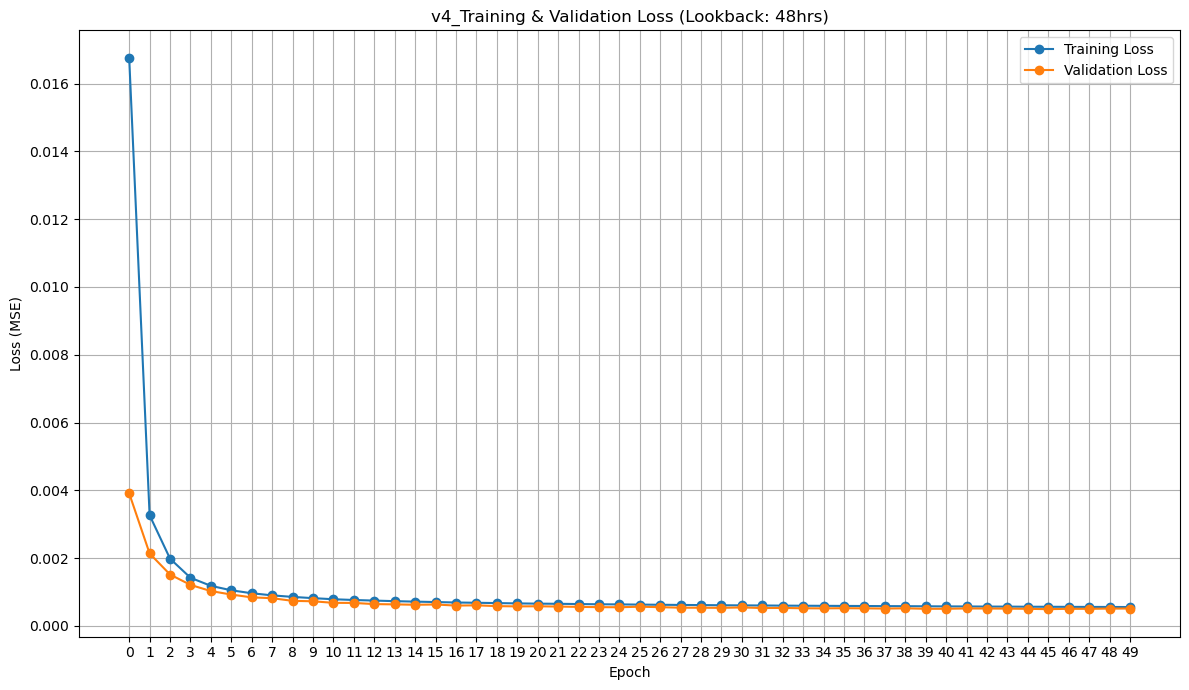

✅ Training history plot saved to 'v4_training_history_lookback_48.png'


In [3]:
# =============================================================================
# NEW CELL: STEP 2.4 - PLOT TRAINING HISTORY
# =============================================================================
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 7))
plt.plot(full_history['train_loss'], label='Training Loss', marker='o')
plt.plot(full_history['val_loss'], label='Validation Loss', marker='o')


plt.xlabel('Epoch')
plt.ylabel('Loss (MSE)')
plt.title(f'{version}_Training & Validation Loss (Lookback: {LOOKBACK_HOURS}hrs)')
plt.legend()
plt.grid(True)
plt.xticks(range(len(full_history['train_loss']))) # Ensure integer ticks for epochs
plt.tight_layout()
plt.savefig(f'{version}_training_history_lookback_{LOOKBACK_HOURS}.png', dpi=300)
plt.show()

print(f"✅ Training history plot saved to '{version}_training_history_lookback_{LOOKBACK_HOURS}.png'")

# STEP 3: EVALUATION AND VISUALIZATION SCRIPT

In [18]:
TOTAL_FORECAST_HOURS = 120
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [23]:
# =============================================================================
# STEP 3: SLIDING WINDOW EVALUATION (30-HOUR FORECAST WITH ERROR CORRECTION)
# =============================================================================
import warnings
warnings.filterwarnings('ignore')

import torch
import torch.nn as nn
import numpy as np
from tqdm.auto import tqdm
import os
import xarray as xr
import pickle
import glob
from torch.utils.data import Dataset, DataLoader
from collections import OrderedDict

print("--- Starting Sliding Window Evaluation (30-hour Forecast) ---\n")

# --- Define Classes (Match Training Architecture) ---
class PreprocessedWaveDataset(Dataset):
    def __init__(self, split_dir):
        self.file_paths = sorted(glob.glob(os.path.join(split_dir, '*.pt')))
    def __len__(self):
        return len(self.file_paths)
    def __getitem__(self, idx):
        return torch.load(self.file_paths[idx])

# ConvGRU Cell (same as training)
class ConvGRUCell(nn.Module):
    def __init__(self, input_dim, hidden_dim, kernel_size, bias=True):
        super().__init__()
        self.hidden_dim = hidden_dim
        padding = kernel_size[0] // 2
        self.conv = nn.Conv2d(
            input_dim + hidden_dim,
            3 * hidden_dim,
            kernel_size,
            padding=padding,
            bias=bias
        )

    def forward(self, x, h):
        gates = self.conv(torch.cat([x, h], dim=1))
        r, z, n = torch.split(gates, self.hidden_dim, dim=1)
        r = torch.sigmoid(r)
        z = torch.sigmoid(z)
        n = torch.tanh(r * h + n)
        return (1 - z) * n + z * h

    def init_hidden(self, b, spatial, device):
        h, w = spatial
        return torch.zeros(b, self.hidden_dim, h, w, device=device)

# Bidirectional ConvGRU (same as training)
class ConvGRU(nn.Module):
    def __init__(self, input_dim, hidden_dim, kernel_size=(3,3), num_layers=1, bidirectional=True):
        super().__init__()
        self.num_layers = num_layers
        self.bidirectional = bidirectional
        self.hidden_dim = hidden_dim

        self.fwd_cells = nn.ModuleList()
        self.bwd_cells = nn.ModuleList() if bidirectional else None

        for i in range(num_layers):
            in_dim = input_dim if i == 0 else hidden_dim * (2 if bidirectional else 1)
            self.fwd_cells.append(ConvGRUCell(in_dim, hidden_dim, kernel_size))
            if bidirectional:
                self.bwd_cells.append(ConvGRUCell(in_dim, hidden_dim, kernel_size))

    def forward(self, x):
        B, T, C, H, W = x.shape
        cur_fwd = x

        for i in range(self.num_layers):
            h = self.fwd_cells[i].init_hidden(B, (H, W), x.device)
            fwd_out = []
            for t in range(T):
                h = self.fwd_cells[i](cur_fwd[:, t], h)
                fwd_out.append(h)
            fwd_out = torch.stack(fwd_out, dim=1)

            if self.bidirectional:
                h = self.bwd_cells[i].init_hidden(B, (H, W), x.device)
                bwd_out = []
                for t in range(T - 1, -1, -1):
                    h = self.bwd_cells[i](cur_fwd[:, t], h)
                    bwd_out.append(h)
                bwd_out.reverse()
                bwd_out = torch.stack(bwd_out, dim=1)
                cur_fwd = torch.cat([fwd_out, bwd_out], dim=2)
            else:
                cur_fwd = fwd_out

        return cur_fwd

# Lightweight DeepLab-style Encoder (same as training)
class LightDeepLabEncoder(nn.Module):
    def __init__(self, input_channels, output_channels=64):
        super().__init__()
        self.stem = nn.Sequential(
            nn.Conv2d(input_channels, 32, 3, padding=1),
            nn.BatchNorm2d(32), nn.ReLU(),
            nn.Conv2d(32, 64, 3, padding=1),
            nn.BatchNorm2d(64), nn.ReLU(),
            nn.Conv2d(64, 128, 3, padding=1),
            nn.BatchNorm2d(128), nn.ReLU(),
        )
        self.aspp1 = nn.Conv2d(128, 32, 1)
        self.aspp2 = nn.Conv2d(128, 32, 3, padding=6,  dilation=6)
        self.aspp3 = nn.Conv2d(128, 16, 3, padding=12, dilation=12)
        self.gap    = nn.AdaptiveAvgPool2d(1)
        self.gap_proj = nn.Conv2d(128, 16, 1)

        self.project = nn.Sequential(
            nn.Conv2d(96, output_channels, 1),
            nn.BatchNorm2d(output_channels),
            nn.ReLU()
        )

    def forward(self, x):
        f = self.stem(x)
        a1 = self.aspp1(f)
        a2 = self.aspp2(f)
        a3 = self.aspp3(f)
        gap = self.gap_proj(self.gap(f))
        gap = gap.expand(-1, -1, f.shape[2], f.shape[3]) 
        return self.project(torch.cat([a1, a2, a3, gap], dim=1))

# Full Model (same as training)
class DeepLabConvGRUNet(nn.Module):
    def __init__(self, input_dim, forecast_horizon, num_output_channels,
                 encoder_out_channels=64, hidden_dims=[32, 16], kernel_size=(3, 3)):
        super().__init__()
        self.forecast_horizon = forecast_horizon
        self.num_output_channels = num_output_channels

        self.encoder = LightDeepLabEncoder(input_dim, encoder_out_channels)

        self.gru1 = ConvGRU(encoder_out_channels, hidden_dims[0], kernel_size, num_layers=1, bidirectional=True)
        self.gru2 = ConvGRU(hidden_dims[0] * 2,   hidden_dims[1], kernel_size, num_layers=1, bidirectional=True)

        self.output_conv = nn.Conv2d(
            hidden_dims[1] * 2,
            forecast_horizon * num_output_channels,
            kernel_size=1
        )

    def forward(self, x_seq):
        B, T, C, H, W = x_seq.shape

        x_flat = x_seq.view(B * T, C, H, W)
        enc = self.encoder(x_flat)
        _, C_enc, H_enc, W_enc = enc.shape
        enc = enc.view(B, T, C_enc, H_enc, W_enc)

        l1 = self.gru1(enc)
        l2 = self.gru2(l1)

        last = l2[:, -1]
        out  = self.output_conv(last)

        if (H_enc, W_enc) != (H, W):
            out = nn.functional.interpolate(out, size=(H, W), mode='bilinear', align_corners=False)

        return out.view(B, self.forecast_horizon, self.num_output_channels, H, W)

# --- Load Scalers ---
try:
    scaler_path = os.path.join(PROCESSED_DATA_DIR, 'scalers_mask.pkl')
    with open(scaler_path, 'rb') as f:
        scalers = pickle.load(f)
    print("✅ Scalers loaded successfully.")
except FileNotFoundError:
    raise SystemExit(f"❌ ERROR: Scalers file not found.")

# --- Load Raw Test Data for Sliding Window ---
ds_test_raw = xr.open_dataset(RAW_DATA_PATH)
ds_test_raw['VSDmag'] = np.sqrt(ds_test_raw['VSDX']**2 + ds_test_raw['VSDY']**2)
ds_test = ds_test_raw[VARS_TO_USE].sel(time=slice('2023-07-01', '2023-12-30')).astype(np.float32).fillna(0)
print(f"✅ Raw test data loaded: {len(ds_test['time'])} time steps")

# Load static features
ds_static = xr.open_dataset(STATIC_DATA_PATH)
ocean_depth = ds_static['deptho'].values.astype(np.float32)
ocean_mask = ds_static['mask'].values.astype(np.float32)
scaled_depth = scalers['ocean_depth'].transform(ocean_depth.reshape(-1, 1)).reshape(ocean_depth.shape)
scaled_depth_ch = np.expand_dims(scaled_depth, axis=0)
ocean_mask_ch = np.expand_dims(ocean_mask, axis=0)
static_features_np = np.concatenate([scaled_depth_ch, ocean_mask_ch], axis=0)

# Load the model
try:
    print(f"Loading weights from: {best_model_path}")
    checkpoint = torch.load(best_model_path, map_location=device)
    new_state_dict = OrderedDict()
    for k, v in checkpoint['state_dict'].items():
        if k.startswith('model.'):
            new_state_dict[k[6:]] = v
        else:
            new_state_dict[k] = v
    model = DeepLabConvGRUNet(input_dim=INPUT_CHANNELS, forecast_horizon=FORECAST_HORIZON_HOURS, 
                              num_output_channels=NUM_OUTPUT_CHANNELS)
    model.load_state_dict(new_state_dict)
except FileNotFoundError:
    raise SystemExit(f"❌ ERROR: Model file not found at '{best_model_path}'.")

if torch.cuda.device_count() > 1:
    model = nn.DataParallel(model)
model.to(device)
model.eval()
print("✅ Model loaded and ready for sliding window evaluation.")

# --- Sliding Window Prediction Function ---
def sliding_window_forecast(ds_test, static_features, model, scalers, lookback_hours, forecast_hours, total_forecast, correction_window, device):
    all_predictions = []
    all_targets = []
    
    num_slides = (total_forecast - forecast_hours) // 1 + 1
    
    print(f"\n--- Starting Sliding Window (Lookback={lookback_hours}h, Predict={forecast_hours}h per step, Total={total_forecast}h) ---")
    
    with torch.no_grad():
        for slide_idx in tqdm(range(num_slides), desc="Sliding Window Steps"):
            start_idx = slide_idx
            lookback_end = start_idx + lookback_hours
            forecast_end = lookback_end + forecast_hours
            
            if forecast_end > len(ds_test['time']):
                break
            
            lookback_window = ds_test.isel(time=slice(start_idx, lookback_end))
            scaled_lookback = []
            for var in VARS_TO_USE:
                data = lookback_window[var].values
                scaled_data = scalers[var].transform(data.reshape(-1, 1)).reshape(data.shape)
                scaled_lookback.append(scaled_data)
            
            scaled_tensor = np.stack(scaled_lookback, axis=1)
            X_tv_np = scaled_tensor[:, :, :, :]
            static_tiled = np.tile(static_features, (lookback_hours, 1, 1, 1))
            X_final = np.concatenate([X_tv_np, static_tiled], axis=1)
            
            X_input = torch.from_numpy(X_final.astype(np.float32)).unsqueeze(0).to(device)
            
            pred_scaled = model(X_input)
            
            target_window = ds_test.isel(time=slice(lookback_end, forecast_end))
            scaled_target = []
            for var in VARS_TO_USE:
                data = target_window[var].values
                scaled_data = scalers[var].transform(data.reshape(-1, 1)).reshape(data.shape)
                scaled_target.append(scaled_data)
            
            scaled_target_tensor = np.stack(scaled_target, axis=1)
            
            pred_inverse = pred_scaled.cpu().numpy()[0]
            pred_original = np.zeros_like(pred_inverse)
            for var_idx, var in enumerate(VARS_TO_USE):
                pred_original[:, var_idx] = scalers[var].inverse_transform(pred_inverse[:, var_idx].reshape(-1, 1)).reshape(pred_inverse[:, var_idx].shape)
            
            target_original = np.zeros_like(scaled_target_tensor)
            for var_idx, var in enumerate(VARS_TO_USE):
                target_original[:, var_idx] = scalers[var].inverse_transform(scaled_target_tensor[:, var_idx].reshape(-1, 1)).reshape(scaled_target_tensor[:, var_idx].shape)
            
            all_predictions.append(pred_original[0])
            all_targets.append(target_original[0])
    
    predictions_30h = np.stack(all_predictions[:total_forecast])
    targets_30h = np.stack(all_targets[:total_forecast])
    
    return predictions_30h, targets_30h

# --- Run Sliding Window Evaluation ---
predictions_30h, targets_30h = sliding_window_forecast(
    ds_test, static_features_np, model, scalers, LOOKBACK_HOURS, FORECAST_HORIZON_HOURS,
    TOTAL_FORECAST_HOURS, CORRECTION_WINDOW, device
)

print(f"\n✅ Sliding window forecast complete!")
print(f"   Predictions shape: {predictions_30h.shape}")
print(f"   Targets shape: {targets_30h.shape}")

# Compute metrics
overall_rmse_30h = np.sqrt(np.mean((predictions_30h - targets_30h) ** 2))
overall_mae_30h = np.mean(np.abs(predictions_30h - targets_30h))
print(f"\n📊 30-Hour Forecast Metrics:")
print(f"   Overall RMSE: {overall_rmse_30h:.4f}")
print(f"   Overall MAE:  {overall_mae_30h:.4f}")


--- Starting Sliding Window Evaluation (30-hour Forecast) ---

✅ Scalers loaded successfully.
✅ Raw test data loaded: 4392 time steps
Loading weights from: /home/aidl/Wave-Prediction/models/v4_deeplabconvgru-lookback48-multivar-epoch=45-val_loss=0.0005.ckpt
✅ Model loaded and ready for sliding window evaluation.

--- Starting Sliding Window (Lookback=48h, Predict=3h per step, Total=120h) ---


Sliding Window Steps:   0%|          | 0/118 [00:00<?, ?it/s]


✅ Sliding window forecast complete!
   Predictions shape: (118, 8, 72, 90)
   Targets shape: (118, 8, 72, 90)

📊 30-Hour Forecast Metrics:
   Overall RMSE: 0.1904
   Overall MAE:  0.0943



--- Generating Sliding Window Visualizations ---

📊 Per-Variable 30-Hour Metrics:
  VCMX: RMSE=0.0998, MAE=0.0738
  VHM0_SW1: RMSE=0.0675, MAE=0.0475
  VSDmag: RMSE=0.0042, MAE=0.0030
  VHM0_WW: RMSE=0.0572, MAE=0.0432
  VTM01_WW: RMSE=0.1650, MAE=0.1167
  VTM02: RMSE=0.1158, MAE=0.0848
  VTM01_SW1: RMSE=0.4146, MAE=0.2761
  VTM10: RMSE=0.1543, MAE=0.1089

--- Generating Visualization: Error Evolution Over 30 Hours ---


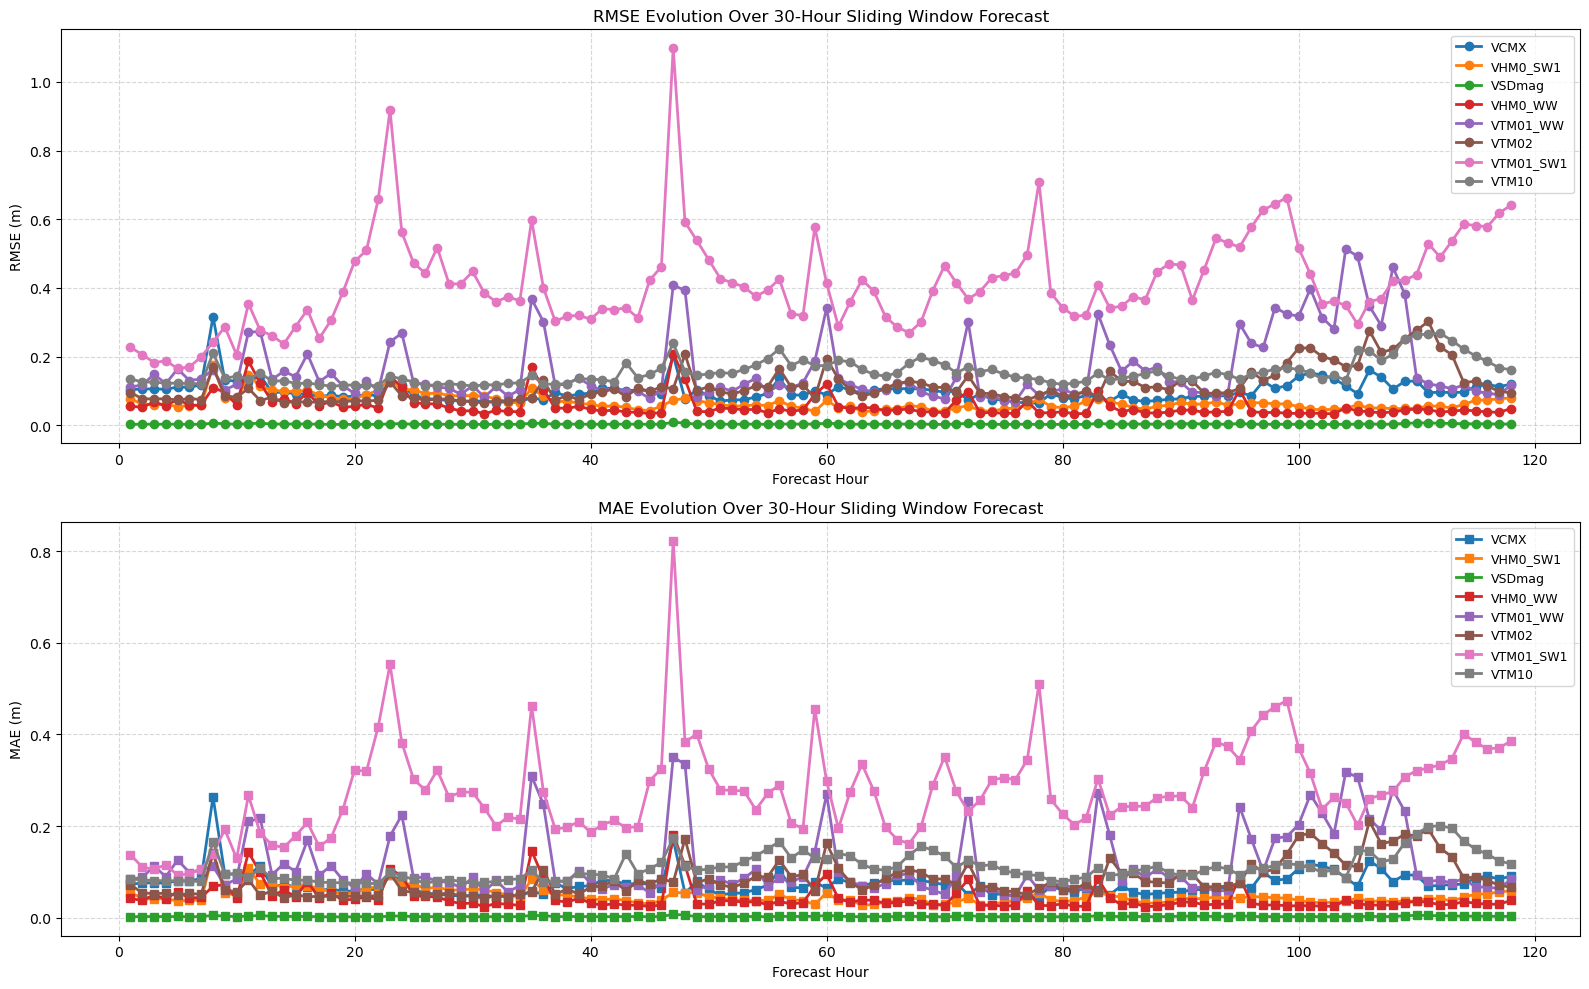

✅ Saved 'v4_sliding_window_30h_errors.png'

--- Generating Visualization: Aggregated Metrics Over 30 Hours ---


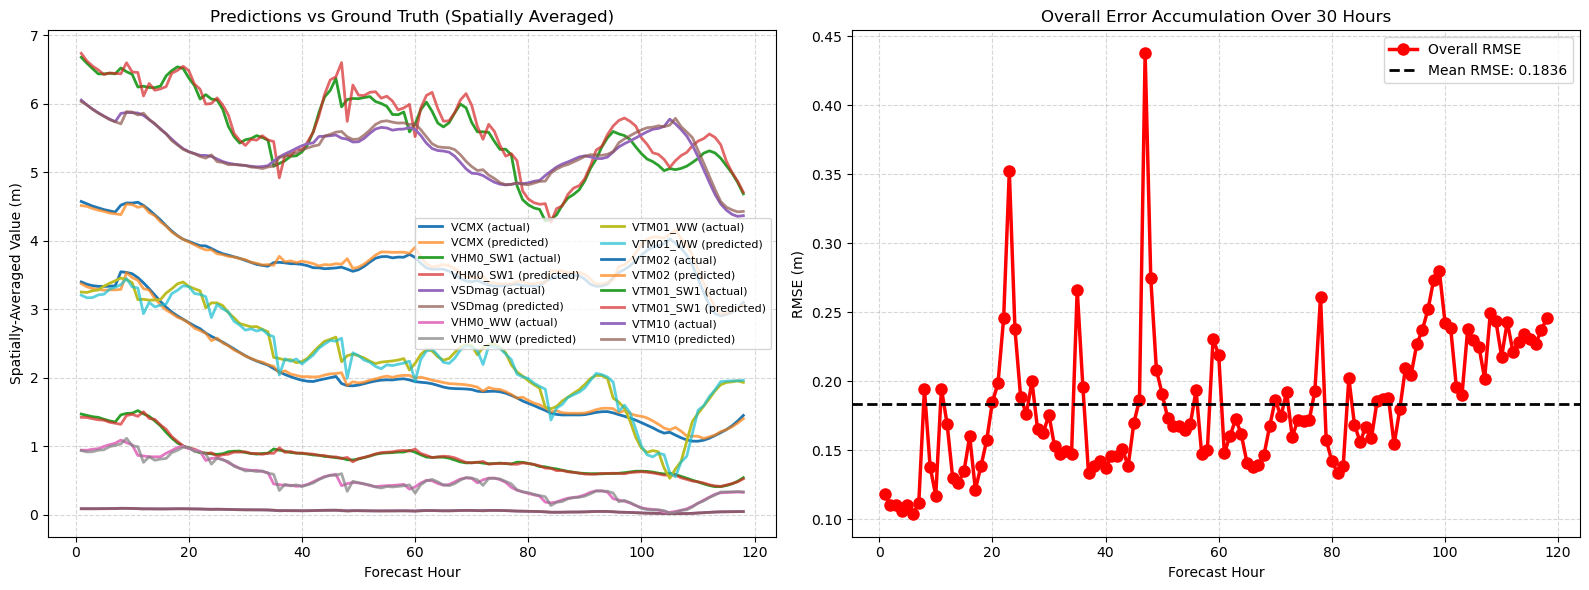

✅ Saved 'v4_sliding_window_30h_predictions.png'

--- Generating Visualization: Prediction Accuracy Scatter ---


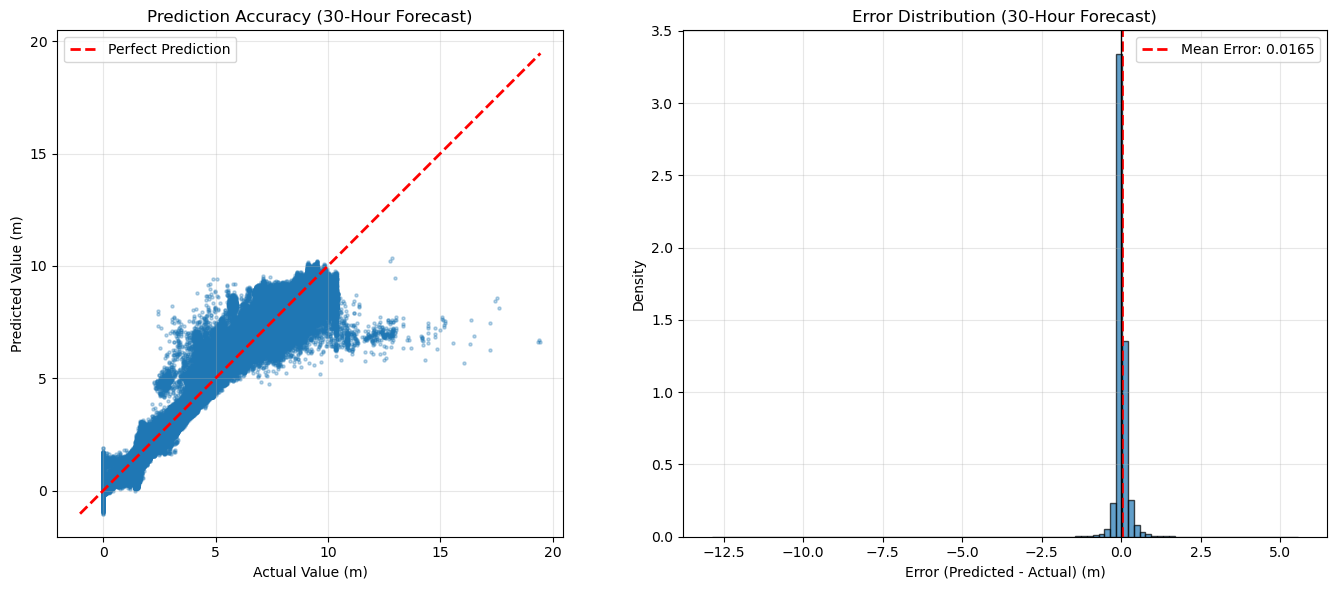

✅ Saved 'v4_sliding_window_30h_accuracy.png'

✅ All sliding window visualizations complete!


In [24]:
# =============================================================================
# STEP 3, PART 2: SLIDING WINDOW VISUALIZATION (30-HOUR FORECAST)
# =============================================================================
import matplotlib.pyplot as plt
import numpy as np

print("\n--- Generating Sliding Window Visualizations ---\n")

# --- Per-Variable Metrics ---
print("📊 Per-Variable 30-Hour Metrics:")
hourly_rmse_per_var = {}
hourly_mae_per_var = {}

for var_idx, var in enumerate(TARGET_VARS):
    pred_var = predictions_30h[:, var_idx, :, :]
    target_var = targets_30h[:, var_idx, :, :]
    
    hourly_rmse = np.sqrt(np.mean((pred_var - target_var) ** 2, axis=(1, 2)))  # RMSE per hour
    hourly_mae = np.mean(np.abs(pred_var - target_var), axis=(1, 2))  # MAE per hour
    
    hourly_rmse_per_var[var] = hourly_rmse
    hourly_mae_per_var[var] = hourly_mae
    
    overall_var_rmse = np.mean(hourly_rmse)
    overall_var_mae = np.mean(hourly_mae)
    print(f"  {var}: RMSE={overall_var_rmse:.4f}, MAE={overall_var_mae:.4f}")

# --- Plot 1: RMSE/MAE across 30 hours for all variables ---
print("\n--- Generating Visualization: Error Evolution Over 30 Hours ---")
hours = np.arange(1, len(predictions_30h) + 1)

fig, axes = plt.subplots(2, 1, figsize=(16, 10))

# RMSE plot
for var in TARGET_VARS:
    axes[0].plot(hours, hourly_rmse_per_var[var], marker='o', label=var, linewidth=2)
axes[0].set_xlabel('Forecast Hour')
axes[0].set_ylabel('RMSE (m)')
axes[0].set_title('RMSE Evolution Over 30-Hour Sliding Window Forecast')
axes[0].legend(loc='best', fontsize=9)
axes[0].grid(True, linestyle='--', alpha=0.5)

# MAE plot
for var in TARGET_VARS:
    axes[1].plot(hours, hourly_mae_per_var[var], marker='s', label=var, linewidth=2)
axes[1].set_xlabel('Forecast Hour')
axes[1].set_ylabel('MAE (m)')
axes[1].set_title('MAE Evolution Over 30-Hour Sliding Window Forecast')
axes[1].legend(loc='best', fontsize=9)
axes[1].grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig(f'{version}_sliding_window_30h_errors.png', dpi=300)
plt.show()
print(f"✅ Saved '{version}_sliding_window_30h_errors.png'")

# --- Plot 2: Aggregated Metrics (spatially-averaged) ---
print("\n--- Generating Visualization: Aggregated Metrics Over 30 Hours ---")
pred_spatial_mean = np.mean(predictions_30h, axis=(2, 3))  # (30h, 7vars)
target_spatial_mean = np.mean(targets_30h, axis=(2, 3))  # (30h, 7vars)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot predictions vs targets for each variable
for var_idx, var in enumerate(TARGET_VARS):
    axes[0].plot(hours, target_spatial_mean[:, var_idx], label=f'{var} (actual)', linewidth=2)
    axes[0].plot(hours, pred_spatial_mean[:, var_idx], label=f'{var} (predicted)', linewidth=2, alpha=0.7)

axes[0].set_xlabel('Forecast Hour')
axes[0].set_ylabel('Spatially-Averaged Value (m)')
axes[0].set_title('Predictions vs Ground Truth (Spatially Averaged)')
axes[0].legend(loc='best', fontsize=8, ncol=2)
axes[0].grid(True, linestyle='--', alpha=0.5)

# Plot overall error across hours
overall_hourly_error = np.sqrt(np.mean((predictions_30h - targets_30h) ** 2, axis=(1, 2, 3)))  # (30h,)
axes[1].plot(hours, overall_hourly_error, 'r-o', linewidth=2.5, markersize=8, label='Overall RMSE')
axes[1].axhline(y=np.mean(overall_hourly_error), color='k', linestyle='--', linewidth=2, label=f'Mean RMSE: {np.mean(overall_hourly_error):.4f}')
axes[1].set_xlabel('Forecast Hour')
axes[1].set_ylabel('RMSE (m)')
axes[1].set_title('Overall Error Accumulation Over 30 Hours')
axes[1].legend(loc='best')
axes[1].grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig(f'{version}_sliding_window_30h_predictions.png', dpi=300)
plt.show()
print(f"✅ Saved '{version}_sliding_window_30h_predictions.png'")

# --- Plot 3: Scatter plot for all predictions ---
print("\n--- Generating Visualization: Prediction Accuracy Scatter ---")
all_preds_flat = predictions_30h.flatten()
all_targets_flat = targets_30h.flatten()

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Scatter plot
axes[0].scatter(all_targets_flat, all_preds_flat, alpha=0.3, s=5)
min_val = min(all_targets_flat.min(), all_preds_flat.min())
max_val = max(all_targets_flat.max(), all_preds_flat.max())
axes[0].plot([min_val, max_val], [min_val, max_val], 'r--', lw=2, label='Perfect Prediction')
axes[0].set_xlabel('Actual Value (m)')
axes[0].set_ylabel('Predicted Value (m)')
axes[0].set_title('Prediction Accuracy (30-Hour Forecast)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)
axes[0].set_aspect('equal')

# Error distribution
errors = all_preds_flat - all_targets_flat
axes[1].hist(errors, bins=100, density=True, alpha=0.7, edgecolor='black')
axes[1].axvline(np.mean(errors), color='r', linestyle='--', lw=2, label=f'Mean Error: {np.mean(errors):.4f}')
axes[1].axvline(0, color='k', linestyle='-', lw=1)
axes[1].set_xlabel('Error (Predicted - Actual) (m)')
axes[1].set_ylabel('Density')
axes[1].set_title('Error Distribution (30-Hour Forecast)')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f'{version}_sliding_window_30h_accuracy.png', dpi=300)
plt.show()
print(f"✅ Saved '{version}_sliding_window_30h_accuracy.png'")

print("\n✅ All sliding window visualizations complete!")


--- Generating VCMX-Only Visualizations ---

--- Generating VCMX Error Evolution Plot ---


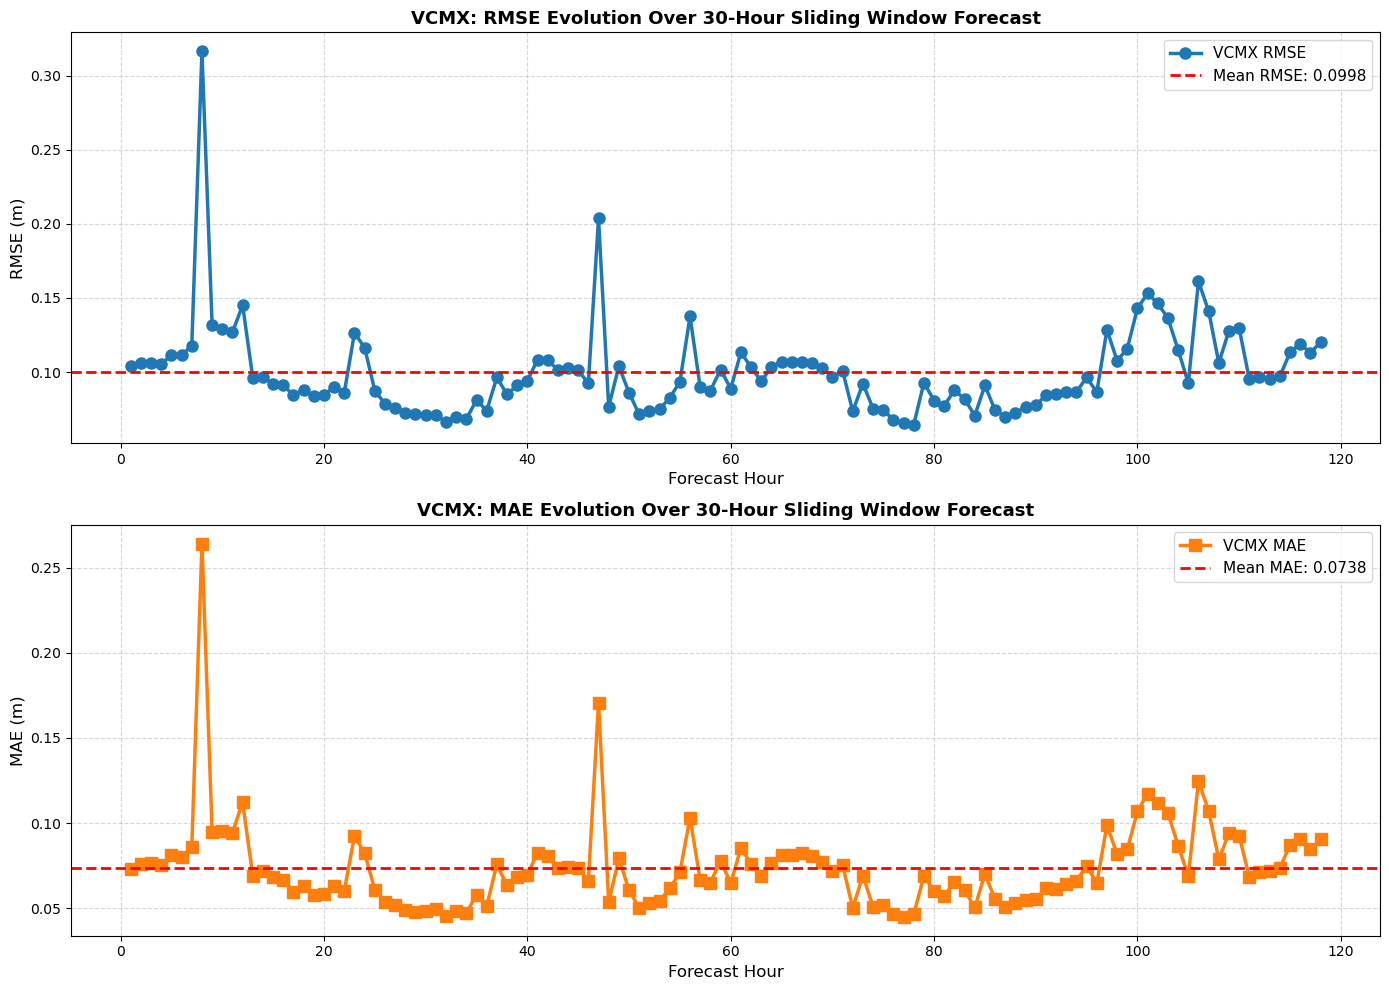

✅ Saved 'v4_VCMX_only_error_evolution.png'

--- Generating VCMX Predictions vs Ground Truth Plot ---


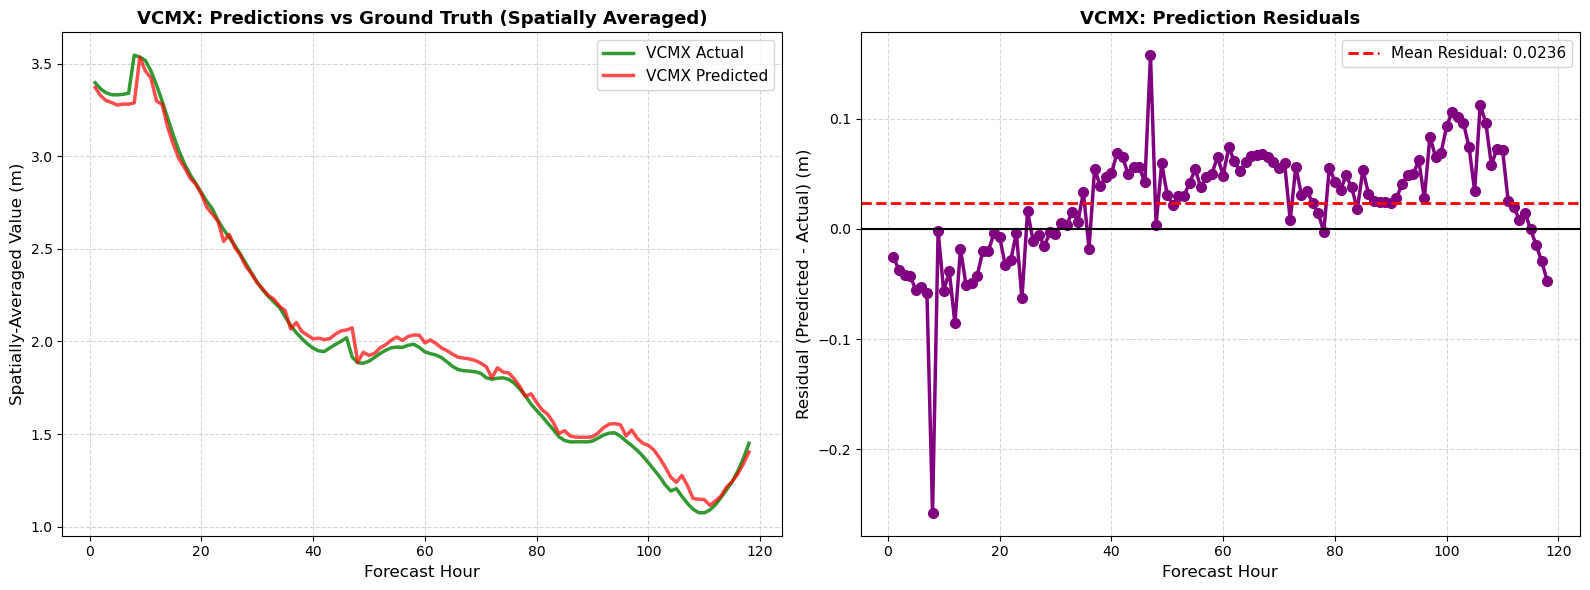

✅ Saved 'v4_VCMX_only_predictions.png'

--- Generating VCMX Scatter and Error Distribution Plot ---


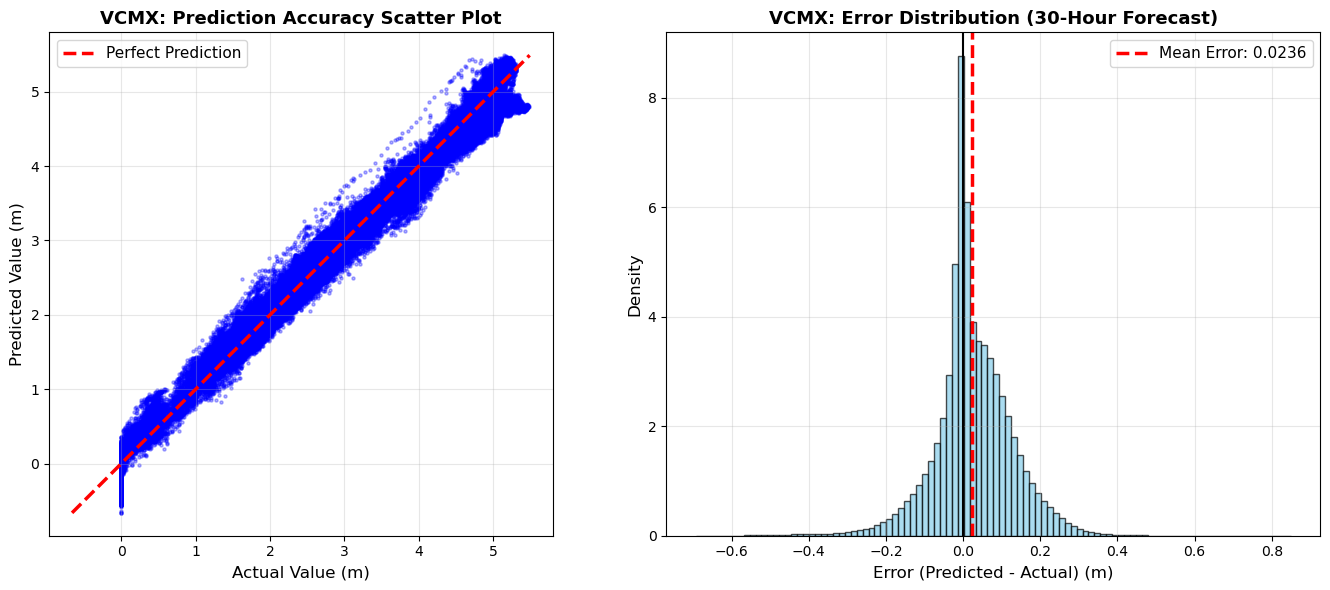

✅ Saved 'v4_VCMX_only_accuracy.png'

VCMX 30-HOUR FORECAST SUMMARY STATISTICS
Overall RMSE: 0.1043 m
Overall MAE:  0.0738 m
Mean RMSE per hour: 0.0998 m
Mean MAE per hour:  0.0738 m
Min RMSE: 0.0646 m (Hour 78)
Max RMSE: 0.3166 m (Hour 8)
Mean Prediction Error: 0.0236 m
Std Dev of Errors: 0.1016 m

✅ All VCMX-only visualizations complete!


In [25]:
# =============================================================================
# VISUALIZATION FOR VCMX VARIABLE ONLY
# =============================================================================

print("\n--- Generating VCMX-Only Visualizations ---\n")

# Extract VCMX data (first variable, index 0)
vcmx_idx = 0
pred_vcmx = predictions_30h[:, vcmx_idx, :, :]  # (30h, H, W)
target_vcmx = targets_30h[:, vcmx_idx, :, :]    # (30h, H, W)

hours = np.arange(1, len(predictions_30h) + 1)

# --- Plot 1: VCMX Error Evolution ---
print("--- Generating VCMX Error Evolution Plot ---")
vcmx_rmse = np.sqrt(np.mean((pred_vcmx - target_vcmx) ** 2, axis=(1, 2)))
vcmx_mae = np.mean(np.abs(pred_vcmx - target_vcmx), axis=(1, 2))

fig, axes = plt.subplots(2, 1, figsize=(14, 10))

axes[0].plot(hours, vcmx_rmse, marker='o', color='#1f77b4', linewidth=2.5, markersize=8, label='VCMX RMSE')
axes[0].axhline(y=np.mean(vcmx_rmse), color='r', linestyle='--', linewidth=2, label=f'Mean RMSE: {np.mean(vcmx_rmse):.4f}')
axes[0].set_xlabel('Forecast Hour', fontsize=12)
axes[0].set_ylabel('RMSE (m)', fontsize=12)
axes[0].set_title('VCMX: RMSE Evolution Over 30-Hour Sliding Window Forecast', fontsize=13, fontweight='bold')
axes[0].legend(loc='best', fontsize=11)
axes[0].grid(True, linestyle='--', alpha=0.5)

axes[1].plot(hours, vcmx_mae, marker='s', color='#ff7f0e', linewidth=2.5, markersize=8, label='VCMX MAE')
axes[1].axhline(y=np.mean(vcmx_mae), color='r', linestyle='--', linewidth=2, label=f'Mean MAE: {np.mean(vcmx_mae):.4f}')
axes[1].set_xlabel('Forecast Hour', fontsize=12)
axes[1].set_ylabel('MAE (m)', fontsize=12)
axes[1].set_title('VCMX: MAE Evolution Over 30-Hour Sliding Window Forecast', fontsize=13, fontweight='bold')
axes[1].legend(loc='best', fontsize=11)
axes[1].grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig(f'{version}_VCMX_only_error_evolution.png', dpi=300)
plt.show()
print(f"✅ Saved '{version}_VCMX_only_error_evolution.png'")

# --- Plot 2: VCMX Predictions vs Ground Truth ---
print("\n--- Generating VCMX Predictions vs Ground Truth Plot ---")
pred_vcmx_spatial_mean = np.mean(pred_vcmx, axis=(1, 2))
target_vcmx_spatial_mean = np.mean(target_vcmx, axis=(1, 2))

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].plot(hours, target_vcmx_spatial_mean, color='green', linewidth=2.5, markersize=7, label='VCMX Actual', alpha=0.8)
axes[0].plot(hours, pred_vcmx_spatial_mean, color='red', linewidth=2.5, markersize=7, label='VCMX Predicted', alpha=0.7)
axes[0].set_xlabel('Forecast Hour', fontsize=12)
axes[0].set_ylabel('Spatially-Averaged Value (m)', fontsize=12)
axes[0].set_title('VCMX: Predictions vs Ground Truth (Spatially Averaged)', fontsize=13, fontweight='bold')
axes[0].legend(loc='best', fontsize=11)
axes[0].grid(True, linestyle='--', alpha=0.5)

# Residuals plot
vcmx_residuals = pred_vcmx_spatial_mean - target_vcmx_spatial_mean
axes[1].plot(hours, vcmx_residuals, 'o-', color='purple', linewidth=2.5, markersize=7)
axes[1].axhline(y=0, color='k', linestyle='-', linewidth=1.5)
axes[1].axhline(y=np.mean(vcmx_residuals), color='r', linestyle='--', linewidth=2, label=f'Mean Residual: {np.mean(vcmx_residuals):.4f}')
axes[1].set_xlabel('Forecast Hour', fontsize=12)
axes[1].set_ylabel('Residual (Predicted - Actual) (m)', fontsize=12)
axes[1].set_title('VCMX: Prediction Residuals', fontsize=13, fontweight='bold')
axes[1].legend(loc='best', fontsize=11)
axes[1].grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig(f'{version}_VCMX_only_predictions.png', dpi=300)
plt.show()
print(f"✅ Saved '{version}_VCMX_only_predictions.png'")

# --- Plot 3: VCMX Scatter and Error Distribution ---
print("\n--- Generating VCMX Scatter and Error Distribution Plot ---")
pred_vcmx_flat = pred_vcmx.flatten()
target_vcmx_flat = target_vcmx.flatten()

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

axes[0].scatter(target_vcmx_flat, pred_vcmx_flat, alpha=0.3, s=5, color='blue')
min_val = min(target_vcmx_flat.min(), pred_vcmx_flat.min())
max_val = max(target_vcmx_flat.max(), pred_vcmx_flat.max())
axes[0].plot([min_val, max_val], [min_val, max_val], 'r--', lw=2.5, label='Perfect Prediction')
axes[0].set_xlabel('Actual Value (m)', fontsize=12)
axes[0].set_ylabel('Predicted Value (m)', fontsize=12)
axes[0].set_title('VCMX: Prediction Accuracy Scatter Plot', fontsize=13, fontweight='bold')
axes[0].legend(fontsize=11)
axes[0].grid(True, alpha=0.3)
axes[0].set_aspect('equal')

vcmx_errors = pred_vcmx_flat - target_vcmx_flat
axes[1].hist(vcmx_errors, bins=100, density=True, alpha=0.7, edgecolor='black', color='skyblue')
axes[1].axvline(np.mean(vcmx_errors), color='r', linestyle='--', lw=2.5, label=f'Mean Error: {np.mean(vcmx_errors):.4f}')
axes[1].axvline(0, color='k', linestyle='-', lw=1.5)
axes[1].set_xlabel('Error (Predicted - Actual) (m)', fontsize=12)
axes[1].set_ylabel('Density', fontsize=12)
axes[1].set_title('VCMX: Error Distribution (30-Hour Forecast)', fontsize=13, fontweight='bold')
axes[1].legend(fontsize=11)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f'{version}_VCMX_only_accuracy.png', dpi=300)
plt.show()
print(f"✅ Saved '{version}_VCMX_only_accuracy.png'")

# Print summary statistics
print("\n" + "="*60)
print("VCMX 30-HOUR FORECAST SUMMARY STATISTICS")
print("="*60)
print(f"Overall RMSE: {np.sqrt(np.mean((pred_vcmx - target_vcmx) ** 2)):.4f} m")
print(f"Overall MAE:  {np.mean(np.abs(pred_vcmx - target_vcmx)):.4f} m")
print(f"Mean RMSE per hour: {np.mean(vcmx_rmse):.4f} m")
print(f"Mean MAE per hour:  {np.mean(vcmx_mae):.4f} m")
print(f"Min RMSE: {vcmx_rmse.min():.4f} m (Hour {vcmx_rmse.argmin() + 1})")
print(f"Max RMSE: {vcmx_rmse.max():.4f} m (Hour {vcmx_rmse.argmax() + 1})")
print(f"Mean Prediction Error: {np.mean(vcmx_errors):.4f} m")
print(f"Std Dev of Errors: {np.std(vcmx_errors):.4f} m")
print("="*60 + "\n")

print("✅ All VCMX-only visualizations complete!")


--- Generating Spatial Maps for Hours 10, 20, and 30 ---


10th Hour:
  Actual - Mean: 3.5181, Min: 0.0000, Max: 5.1700
  Predicted - Mean: 3.4617, Min: -0.4953, Max: 5.4335
  Error - Mean: 0.0955, Min: 0.0000, Max: 0.7235

20th Hour:
  Actual - Mean: 2.8047, Min: 0.0000, Max: 4.1800
  Predicted - Mean: 2.7976, Min: -0.5554, Max: 4.5882
  Error - Mean: 0.0583, Min: 0.0000, Max: 0.7640

30th Hour:
  Actual - Mean: 2.3213, Min: 0.0000, Max: 3.6400
  Predicted - Mean: 2.3164, Min: -0.5283, Max: 4.1476
  Error - Mean: 0.0486, Min: 0.0000, Max: 0.6576


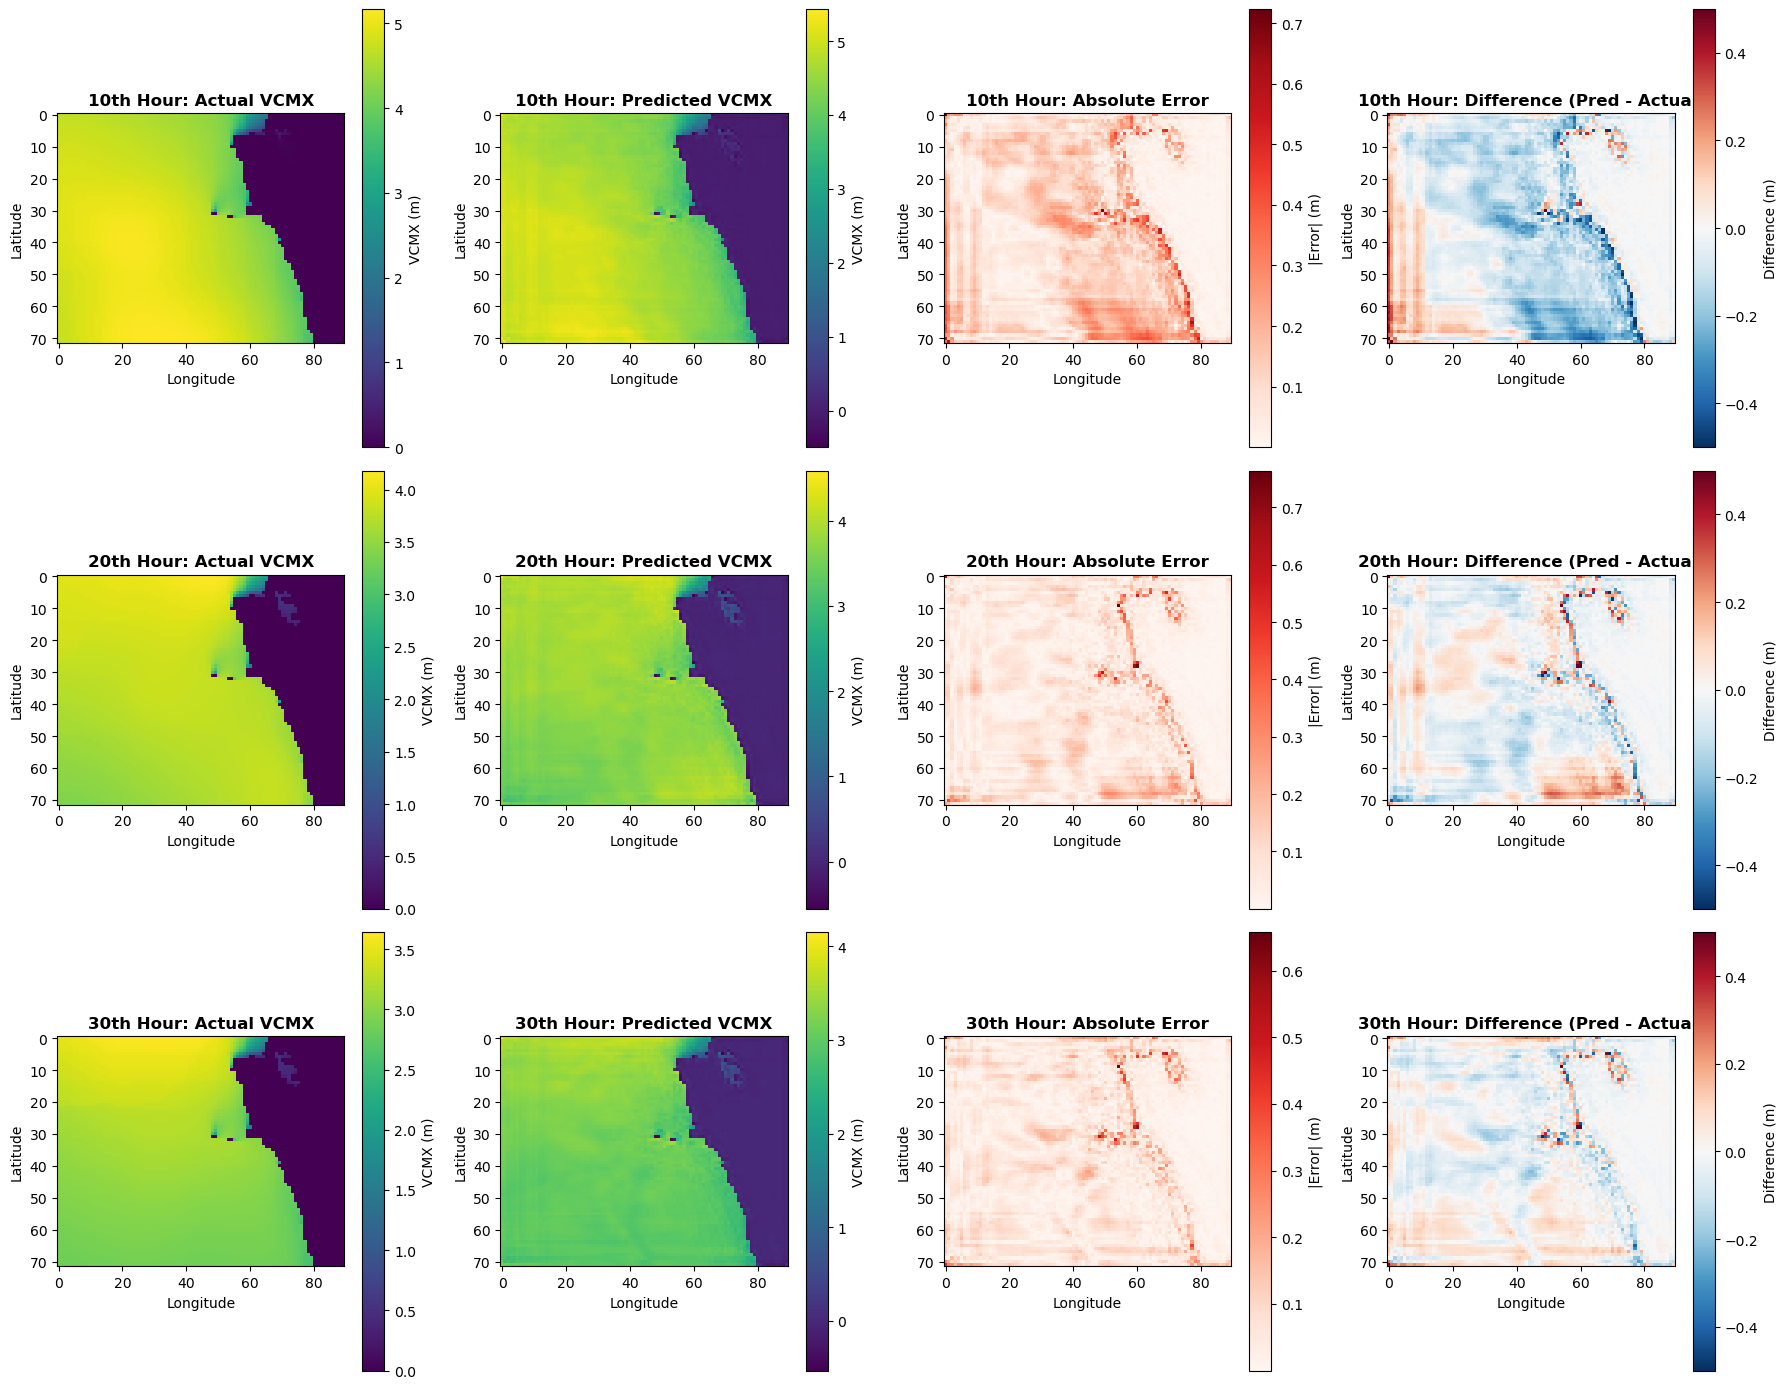


✅ Saved 'v4_spatial_maps_hours_10_20_30.png'


In [26]:
import numpy as np

# =============================================================================
# VISUALIZATION FOR 10TH, 20TH, AND 30TH HOUR SPATIAL MAPS
# =============================================================================

import matplotlib.pyplot as plt

print("\n--- Generating Spatial Maps for Hours 10, 20, and 30 ---\n")

# Select hours: 10th (index 9), 20th (index 19), 30th (index 29)
hours_to_plot = [9, 19, 29]
hour_labels = ['10th Hour', '20th Hour', '30th Hour']

# Create a figure with 3 rows (one per hour) and 4 columns (actual, predicted, error, diff)
fig, axes = plt.subplots(3, 4, figsize=(18, 14))

for row_idx, (hour_idx, hour_label) in enumerate(zip(hours_to_plot, hour_labels)):
    # Get VCMX data for this hour (index 0)
    actual = targets_30h[hour_idx, 0, :, :]  # (H, W)
    predicted = predictions_30h[hour_idx, 0, :, :]  # (H, W)
    error = np.abs(predicted - actual)
    diff = predicted - actual
    
    # Actual values
    im0 = axes[row_idx, 0].imshow(actual, cmap='viridis')
    axes[row_idx, 0].set_title(f'{hour_label}: Actual VCMX', fontsize=12, fontweight='bold')
    axes[row_idx, 0].set_xlabel('Longitude')
    axes[row_idx, 0].set_ylabel('Latitude')
    plt.colorbar(im0, ax=axes[row_idx, 0], label='VCMX (m)')
    
    # Predicted values
    im1 = axes[row_idx, 1].imshow(predicted, cmap='viridis')
    axes[row_idx, 1].set_title(f'{hour_label}: Predicted VCMX', fontsize=12, fontweight='bold')
    axes[row_idx, 1].set_xlabel('Longitude')
    axes[row_idx, 1].set_ylabel('Latitude')
    plt.colorbar(im1, ax=axes[row_idx, 1], label='VCMX (m)')
    
    # Absolute Error
    im2 = axes[row_idx, 2].imshow(error, cmap='Reds')
    axes[row_idx, 2].set_title(f'{hour_label}: Absolute Error', fontsize=12, fontweight='bold')
    axes[row_idx, 2].set_xlabel('Longitude')
    axes[row_idx, 2].set_ylabel('Latitude')
    plt.colorbar(im2, ax=axes[row_idx, 2], label='|Error| (m)')
    
    # Difference (signed)
    im3 = axes[row_idx, 3].imshow(diff, cmap='RdBu_r', vmin=-0.5, vmax=0.5)
    axes[row_idx, 3].set_title(f'{hour_label}: Difference (Pred - Actual)', fontsize=12, fontweight='bold')
    axes[row_idx, 3].set_xlabel('Longitude')
    axes[row_idx, 3].set_ylabel('Latitude')
    plt.colorbar(im3, ax=axes[row_idx, 3], label='Difference (m)')
    
    # Print statistics
    print(f"\n{hour_label}:")
    print(f"  Actual - Mean: {actual.mean():.4f}, Min: {actual.min():.4f}, Max: {actual.max():.4f}")
    print(f"  Predicted - Mean: {predicted.mean():.4f}, Min: {predicted.min():.4f}, Max: {predicted.max():.4f}")
    print(f"  Error - Mean: {error.mean():.4f}, Min: {error.min():.4f}, Max: {error.max():.4f}")

plt.tight_layout()
plt.savefig(f'{version}_spatial_maps_hours_10_20_30.png', dpi=300, bbox_inches='tight')
plt.show()
print(f"\n✅ Saved '{version}_spatial_maps_hours_10_20_30.png'")

## Max VCMX test

In [3]:
best_model_path = '/home/aidl/Wave-Prediction/models/v4_deeplabconvgru-lookback48-multivar-epoch=45-val_loss=0.0005.ckpt'
TOTAL_FORECAST_HOURS = 120
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# lookback_hours = 96

In [ ]:
# =============================================================================
# STEP 5: EXTENDED TESTING - DIFFERENT DATE RANGE (DIFFERENT TIME PERIOD)      
# =============================================================================
import warnings
warnings.filterwarnings('ignore')

import torch
import torch.nn as nn
import numpy as np
from tqdm.auto import tqdm
import os
import xarray as xr
import pickle
import glob
from torch.utils.data import Dataset, DataLoader
from collections import OrderedDict

print("--- Starting Extended Testing (Different Date Range) ---\n")

# --- Define Model Classes (Match Training Architecture) ---
class ConvGRUCell(nn.Module):
    def __init__(self, input_dim, hidden_dim, kernel_size, bias=True):
        super().__init__()
        self.hidden_dim = hidden_dim
        padding = kernel_size[0] // 2
        self.conv = nn.Conv2d(
            input_dim + hidden_dim,
            3 * hidden_dim,
            kernel_size,
            padding=padding,
            bias=bias
        )

    def forward(self, x, h):
        gates = self.conv(torch.cat([x, h], dim=1))
        r, z, n = torch.split(gates, self.hidden_dim, dim=1)
        r = torch.sigmoid(r)
        z = torch.sigmoid(z)
        n = torch.tanh(r * h + n)
        return (1 - z) * n + z * h

    def init_hidden(self, b, spatial, device):
        h, w = spatial
        return torch.zeros(b, self.hidden_dim, h, w, device=device)

class ConvGRU(nn.Module):
    def __init__(self, input_dim, hidden_dim, kernel_size=(3,3), num_layers=1, bidirectional=True):
        super().__init__()
        self.num_layers = num_layers
        self.bidirectional = bidirectional
        self.hidden_dim = hidden_dim

        self.fwd_cells = nn.ModuleList()
        self.bwd_cells = nn.ModuleList() if bidirectional else None

        for i in range(num_layers):
            in_dim = input_dim if i == 0 else hidden_dim * (2 if bidirectional else 1)
            self.fwd_cells.append(ConvGRUCell(in_dim, hidden_dim, kernel_size))
            if bidirectional:
                self.bwd_cells.append(ConvGRUCell(in_dim, hidden_dim, kernel_size))

    def forward(self, x):
        B, T, C, H, W = x.shape
        cur_fwd = x

        for i in range(self.num_layers):
            h = self.fwd_cells[i].init_hidden(B, (H, W), x.device)
            fwd_out = []
            for t in range(T):
                h = self.fwd_cells[i](cur_fwd[:, t], h)
                fwd_out.append(h)
            fwd_out = torch.stack(fwd_out, dim=1)

            if self.bidirectional:
                h = self.bwd_cells[i].init_hidden(B, (H, W), x.device)
                bwd_out = []
                for t in range(T - 1, -1, -1):
                    h = self.bwd_cells[i](cur_fwd[:, t], h)
                    bwd_out.append(h)
                bwd_out.reverse()
                bwd_out = torch.stack(bwd_out, dim=1)
                cur_fwd = torch.cat([fwd_out, bwd_out], dim=2)
            else:
                cur_fwd = fwd_out

        return cur_fwd

class LightDeepLabEncoder(nn.Module):
    def __init__(self, input_channels, output_channels=64):
        super().__init__()
        self.stem = nn.Sequential(
            nn.Conv2d(input_channels, 32, 3, padding=1),
            nn.BatchNorm2d(32), nn.ReLU(),
            nn.Conv2d(32, 64, 3, padding=1),
            nn.BatchNorm2d(64), nn.ReLU(),
            nn.Conv2d(64, 128, 3, padding=1),
            nn.BatchNorm2d(128), nn.ReLU(),
        )
        self.aspp1 = nn.Conv2d(128, 32, 1)
        self.aspp2 = nn.Conv2d(128, 32, 3, padding=6,  dilation=6)
        self.aspp3 = nn.Conv2d(128, 16, 3, padding=12, dilation=12)
        self.gap    = nn.AdaptiveAvgPool2d(1)
        self.gap_proj = nn.Conv2d(128, 16, 1)

        self.project = nn.Sequential(
            nn.Conv2d(96, output_channels, 1),
            nn.BatchNorm2d(output_channels),
            nn.ReLU()
        )

    def forward(self, x):
        f = self.stem(x)
        a1 = self.aspp1(f)
        a2 = self.aspp2(f)
        a3 = self.aspp3(f)
        gap = self.gap_proj(self.gap(f))
        gap = gap.expand(-1, -1, f.shape[2], f.shape[3]) 
        return self.project(torch.cat([a1, a2, a3, gap], dim=1))

class DeepLabConvGRUNet(nn.Module):
    def __init__(self, input_dim, forecast_horizon, num_output_channels,
                 encoder_out_channels=64, hidden_dims=[32, 16], kernel_size=(3, 3)):
        super().__init__()
        self.forecast_horizon = forecast_horizon
        self.num_output_channels = num_output_channels

        self.encoder = LightDeepLabEncoder(input_dim, encoder_out_channels)

        self.gru1 = ConvGRU(encoder_out_channels, hidden_dims[0], kernel_size, num_layers=1, bidirectional=True)
        self.gru2 = ConvGRU(hidden_dims[0] * 2,   hidden_dims[1], kernel_size, num_layers=1, bidirectional=True)

        self.output_conv = nn.Conv2d(
            hidden_dims[1] * 2,
            forecast_horizon * num_output_channels,
            kernel_size=1
        )

    def forward(self, x_seq):
        B, T, C, H, W = x_seq.shape

        x_flat = x_seq.view(B * T, C, H, W)
        enc = self.encoder(x_flat)
        _, C_enc, H_enc, W_enc = enc.shape
        enc = enc.view(B, T, C_enc, H_enc, W_enc)

        l1 = self.gru1(enc)
        l2 = self.gru2(l1)

        last = l2[:, -1]
        out  = self.output_conv(last)

        if (H_enc, W_enc) != (H, W):
            out = nn.functional.interpolate(out, size=(H, W), mode='bilinear', align_corners=False)

        return out.view(B, self.forecast_horizon, self.num_output_channels, H, W)

# --- Load Scalers ---
try:
    scaler_path = os.path.join(PROCESSED_DATA_DIR, 'scalers_mask.pkl')
    with open(scaler_path, 'rb') as f:
        scalers = pickle.load(f)
    print("✅ Scalers loaded successfully.")
except FileNotFoundError:
    raise SystemExit(f"❌ ERROR: Scalers file not found.")

# --- Load Raw Test Data (Different Date Range) ---
ds_test_raw = xr.open_dataset(RAW_DATA_PATH)
ds_test_raw['VSDmag'] = np.sqrt(ds_test_raw['VSDX']**2 + ds_test_raw['VSDY']**2)
ds_test = ds_test_raw[VARS_TO_USE].sel(time=slice('2023-11-02', '2023-11-30')).astype(np.float32).fillna(0)
print(f"✅ Raw test data loaded: {len(ds_test['time'])} time steps (June-July 2022)")

# Load static features
ds_static = xr.open_dataset(STATIC_DATA_PATH)
ocean_depth = ds_static['deptho'].values.astype(np.float32)
ocean_mask = ds_static['mask'].values.astype(np.float32)
scaled_depth = scalers['ocean_depth'].transform(ocean_depth.reshape(-1, 1)).reshape(ocean_depth.shape)
scaled_depth_ch = np.expand_dims(scaled_depth, axis=0)
ocean_mask_ch = np.expand_dims(ocean_mask, axis=0)
static_features_np = np.concatenate([scaled_depth_ch, ocean_mask_ch], axis=0)

# Load the model
try:
    print(f"Loading weights from: {best_model_path}")
    checkpoint = torch.load(best_model_path, map_location=device)
    new_state_dict = OrderedDict()
    for k, v in checkpoint['state_dict'].items():
        if k.startswith('model.'):
            new_state_dict[k[6:]] = v
        else:
            new_state_dict[k] = v
    model = DeepLabConvGRUNet(input_dim=INPUT_CHANNELS, forecast_horizon=FORECAST_HORIZON_HOURS, 
                              num_output_channels=NUM_OUTPUT_CHANNELS)
    model.load_state_dict(new_state_dict)
except FileNotFoundError:
    raise SystemExit(f"❌ ERROR: Model file not found at '{best_model_path}'.")

if torch.cuda.device_count() > 1:
    model = nn.DataParallel(model)
model.to(device)
model.eval()
print("✅ Model loaded and ready for extended testing evaluation.")

# --- Sliding Window Prediction Function (Same as Step 3) ---
def sliding_window_forecast(ds_test, static_features, model, scalers, lookback_hours, forecast_hours, total_forecast, correction_window, device):
    all_predictions = []
    all_targets = []
    
    num_slides = (total_forecast - forecast_hours) // 1 + 1
    
    print(f"\n--- Starting Sliding Window (Lookback={lookback_hours}h, Predict={forecast_hours}h per step, Total={total_forecast}h) ---")
    
    with torch.no_grad():
        for slide_idx in tqdm(range(num_slides), desc="Extended Testing Sliding Window"):
            start_idx = slide_idx
            lookback_end = start_idx + lookback_hours
            forecast_end = lookback_end + forecast_hours
            
            if forecast_end > len(ds_test['time']):
                break
            
            lookback_window = ds_test.isel(time=slice(start_idx, lookback_end))
            scaled_lookback = []
            for var in VARS_TO_USE:
                data = lookback_window[var].values
                scaled_data = scalers[var].transform(data.reshape(-1, 1)).reshape(data.shape)
                scaled_lookback.append(scaled_data)
            
            scaled_tensor = np.stack(scaled_lookback, axis=1)
            X_tv_np = scaled_tensor[:, :, :, :]
            static_tiled = np.tile(static_features, (lookback_hours, 1, 1, 1))
            X_final = np.concatenate([X_tv_np, static_tiled], axis=1)
            
            X_input = torch.from_numpy(X_final.astype(np.float32)).unsqueeze(0).to(device)
            
            pred_scaled = model(X_input)
            
            target_window = ds_test.isel(time=slice(lookback_end, forecast_end))
            scaled_target = []
            for var in VARS_TO_USE:
                data = target_window[var].values
                scaled_data = scalers[var].transform(data.reshape(-1, 1)).reshape(data.shape)
                scaled_target.append(scaled_data)
            
            scaled_target_tensor = np.stack(scaled_target, axis=1)
            
            pred_inverse = pred_scaled.cpu().numpy()[0]
            pred_original = np.zeros_like(pred_inverse)
            for var_idx, var in enumerate(VARS_TO_USE):
                pred_original[:, var_idx] = scalers[var].inverse_transform(pred_inverse[:, var_idx].reshape(-1, 1)).reshape(pred_inverse[:, var_idx].shape)
            
            target_original = np.zeros_like(scaled_target_tensor)
            for var_idx, var in enumerate(VARS_TO_USE):
                target_original[:, var_idx] = scalers[var].inverse_transform(scaled_target_tensor[:, var_idx].reshape(-1, 1)).reshape(scaled_target_tensor[:, var_idx].shape)
            
            all_predictions.append(pred_original[0])
            all_targets.append(target_original[0])
    
    predictions_30h = np.stack(all_predictions[:total_forecast])
    targets_30h = np.stack(all_targets[:total_forecast])
    
    return predictions_30h, targets_30h

# --- Run Extended Testing Evaluation ---
predictions_ext, targets_ext = sliding_window_forecast(
    ds_test, static_features_np, model, scalers, LOOKBACK_HOURS, FORECAST_HORIZON_HOURS,
    TOTAL_FORECAST_HOURS, CORRECTION_WINDOW, device
)

print(f"\n✅ Extended testing forecast complete!")
print(f"   Predictions shape: {predictions_ext.shape}")
print(f"   Targets shape: {targets_ext.shape}")

# Compute metrics
overall_rmse_ext = np.sqrt(np.mean((predictions_ext - targets_ext) ** 2))
overall_mae_ext = np.mean(np.abs(predictions_ext - targets_ext))
print(f"\n📊 Extended Testing (June-July 2022) Metrics:")
print(f"   Overall RMSE: {overall_rmse_ext:.4f}")
print(f"   Overall MAE:  {overall_mae_ext:.4f}")


--- Starting Extended Testing (Different Date Range) ---

✅ Scalers loaded successfully.
✅ Raw test data loaded: 696 time steps (June-July 2022)
Loading weights from: /home/aidl/Wave-Prediction/models/v4_deeplabconvgru-lookback48-multivar-epoch=45-val_loss=0.0005.ckpt
✅ Model loaded and ready for extended testing evaluation.

--- Starting Sliding Window (Lookback=48h, Predict=3h per step, Total=120h) ---


Extended Testing Sliding Window:   0%|          | 0/118 [00:00<?, ?it/s]


✅ Extended testing forecast complete!
   Predictions shape: (118, 8, 72, 90)
   Targets shape: (118, 8, 72, 90)

📊 Extended Testing (June-July 2022) Metrics:
   Overall RMSE: 0.2681
   Overall MAE:  0.1455



--- Generating VCMX-Only Visualizations (Extended Testing) ---

--- Generating VCMX Error Evolution Plot ---


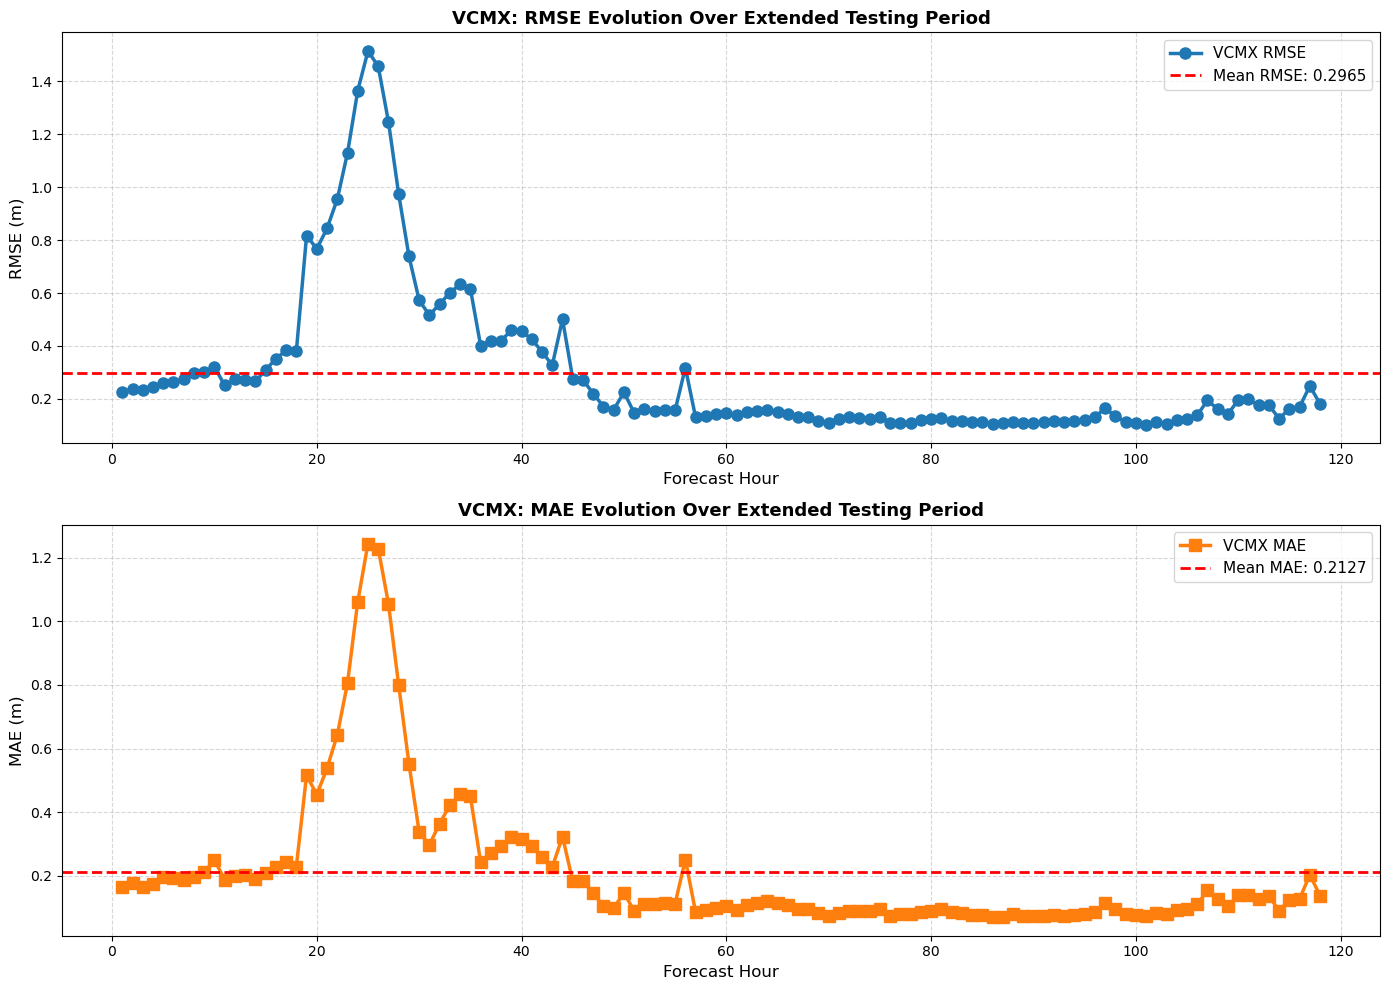

✅ Saved 'v4_VCMX_ext_error_evolution.png'

--- Generating VCMX Predictions vs Ground Truth Plot ---


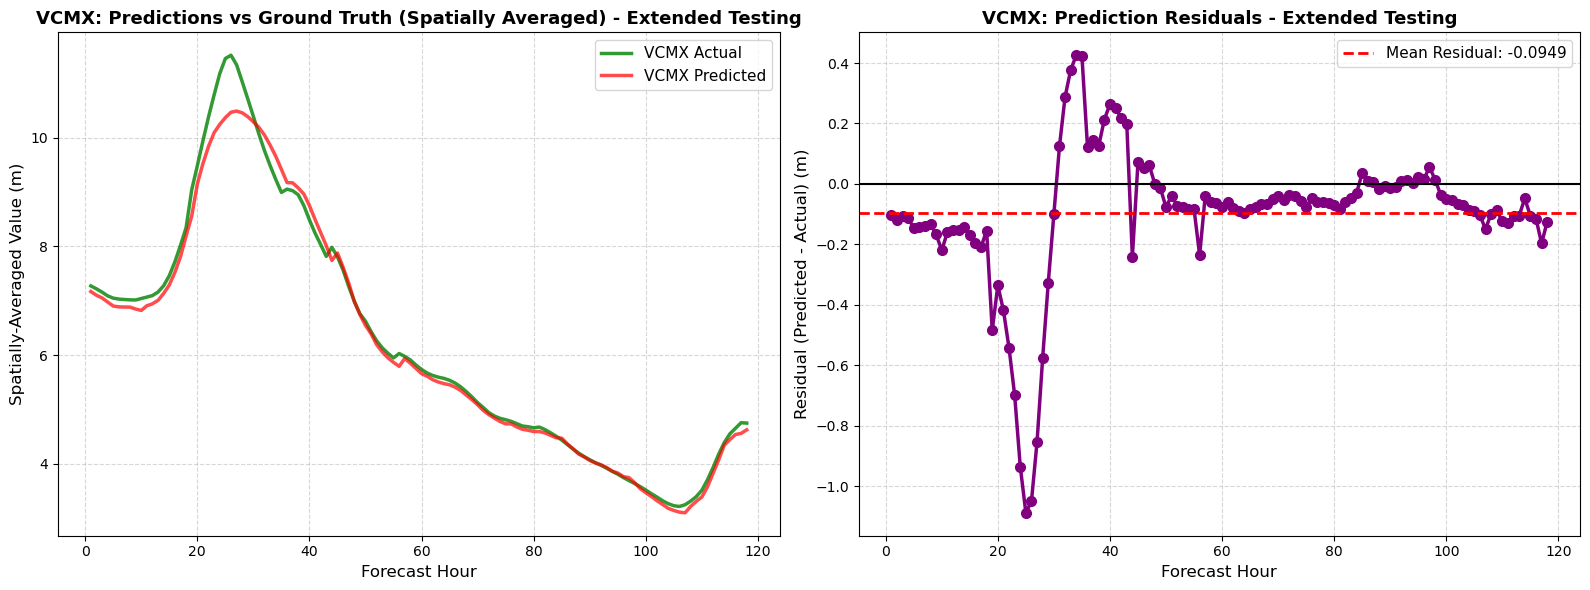

✅ Saved 'v4_VCMX_ext_predictions.png'

--- Generating VCMX Scatter and Error Distribution Plot ---


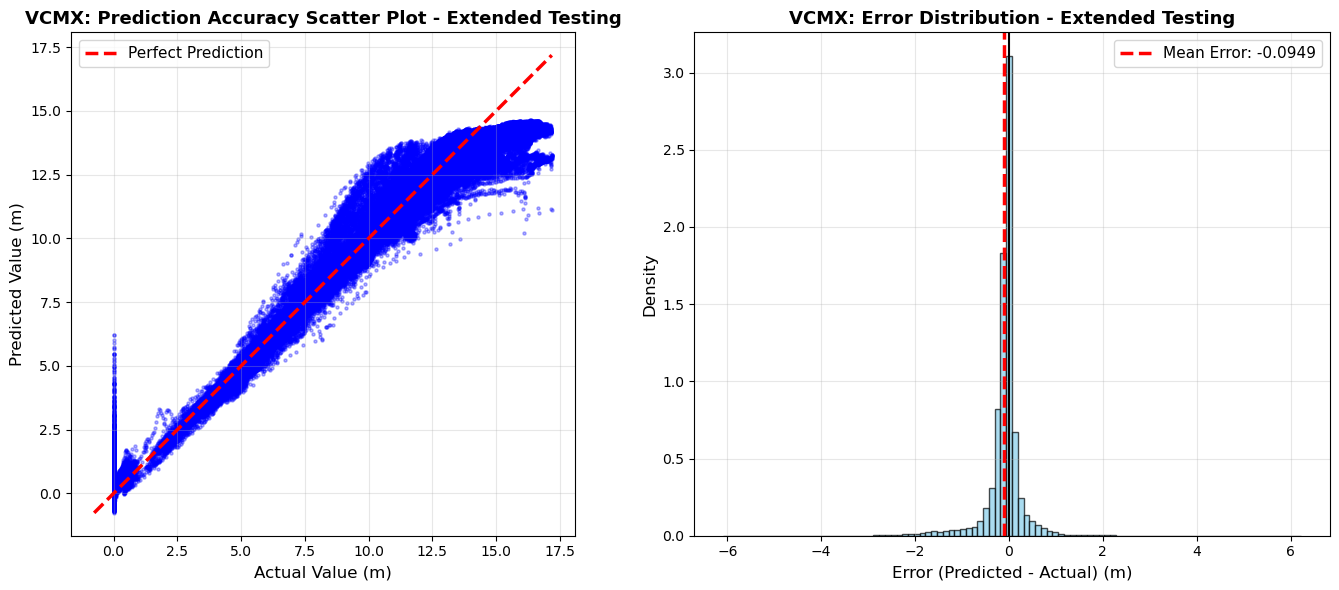

✅ Saved 'v4_VCMX_ext_accuracy.png'

VCMX EXTENDED TESTING SUMMARY STATISTICS
Overall RMSE: 0.4153 m
Overall MAE:  0.2127 m
Mean RMSE per hour: 0.2965 m
Mean MAE per hour:  0.2127 m
Min RMSE: 0.1028 m (Hour 101)
Max RMSE: 1.5151 m (Hour 25)
Mean Prediction Error: -0.0949 m
Std Dev of Errors: 0.4043 m

✅ All VCMX-only visualizations complete!


In [6]:
# =============================================================================
# VISUALIZATION FOR VCMX VARIABLE ONLY (EXTENDED TESTING)
# =============================================================================
import matplotlib.pyplot as plt

print("\n--- Generating VCMX-Only Visualizations (Extended Testing) ---\n")

# Extract VCMX data (first variable, index 0) from extended testing
vcmx_idx = 0
pred_vcmx = predictions_ext[:, vcmx_idx, :, :]  # (ext, H, W)
target_vcmx = targets_ext[:, vcmx_idx, :, :]    # (ext, H, W)

hours = np.arange(1, len(predictions_ext) + 1)

# --- Plot 1: VCMX Error Evolution ---
print("--- Generating VCMX Error Evolution Plot ---")
vcmx_rmse = np.sqrt(np.mean((pred_vcmx - target_vcmx) ** 2, axis=(1, 2)))
vcmx_mae = np.mean(np.abs(pred_vcmx - target_vcmx), axis=(1, 2))

fig, axes = plt.subplots(2, 1, figsize=(14, 10))

axes[0].plot(hours, vcmx_rmse, marker='o', color='#1f77b4', linewidth=2.5, markersize=8, label='VCMX RMSE')
axes[0].axhline(y=np.mean(vcmx_rmse), color='r', linestyle='--', linewidth=2, label=f'Mean RMSE: {np.mean(vcmx_rmse):.4f}')
axes[0].set_xlabel('Forecast Hour', fontsize=12)
axes[0].set_ylabel('RMSE (m)', fontsize=12)
axes[0].set_title('VCMX: RMSE Evolution Over Extended Testing Period', fontsize=13, fontweight='bold')
axes[0].legend(loc='best', fontsize=11)
axes[0].grid(True, linestyle='--', alpha=0.5)

axes[1].plot(hours, vcmx_mae, marker='s', color='#ff7f0e', linewidth=2.5, markersize=8, label='VCMX MAE')
axes[1].axhline(y=np.mean(vcmx_mae), color='r', linestyle='--', linewidth=2, label=f'Mean MAE: {np.mean(vcmx_mae):.4f}')
axes[1].set_xlabel('Forecast Hour', fontsize=12)
axes[1].set_ylabel('MAE (m)', fontsize=12)
axes[1].set_title('VCMX: MAE Evolution Over Extended Testing Period', fontsize=13, fontweight='bold')
axes[1].legend(loc='best', fontsize=11)
axes[1].grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig(f'{version}_VCMX_ext_error_evolution.png', dpi=300)
plt.show()
print(f"✅ Saved '{version}_VCMX_ext_error_evolution.png'")

# --- Plot 2: VCMX Predictions vs Ground Truth ---
print("\n--- Generating VCMX Predictions vs Ground Truth Plot ---")
pred_vcmx_spatial_mean = np.mean(pred_vcmx, axis=(1, 2))
target_vcmx_spatial_mean = np.mean(target_vcmx, axis=(1, 2))

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].plot(hours, target_vcmx_spatial_mean, color='green', linewidth=2.5, markersize=7, label='VCMX Actual', alpha=0.8)
axes[0].plot(hours, pred_vcmx_spatial_mean, color='red', linewidth=2.5, markersize=7, label='VCMX Predicted', alpha=0.7)
axes[0].set_xlabel('Forecast Hour', fontsize=12)
axes[0].set_ylabel('Spatially-Averaged Value (m)', fontsize=12)
axes[0].set_title('VCMX: Predictions vs Ground Truth (Spatially Averaged) - Extended Testing', fontsize=13, fontweight='bold')
axes[0].legend(loc='best', fontsize=11)
axes[0].grid(True, linestyle='--', alpha=0.5)

# Residuals plot
vcmx_residuals = pred_vcmx_spatial_mean - target_vcmx_spatial_mean
axes[1].plot(hours, vcmx_residuals, 'o-', color='purple', linewidth=2.5, markersize=7)
axes[1].axhline(y=0, color='k', linestyle='-', linewidth=1.5)
axes[1].axhline(y=np.mean(vcmx_residuals), color='r', linestyle='--', linewidth=2, label=f'Mean Residual: {np.mean(vcmx_residuals):.4f}')
axes[1].set_xlabel('Forecast Hour', fontsize=12)
axes[1].set_ylabel('Residual (Predicted - Actual) (m)', fontsize=12)
axes[1].set_title('VCMX: Prediction Residuals - Extended Testing', fontsize=13, fontweight='bold')
axes[1].legend(loc='best', fontsize=11)
axes[1].grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig(f'{version}_VCMX_ext_predictions.png', dpi=300)
plt.show()
print(f"✅ Saved '{version}_VCMX_ext_predictions.png'")

# --- Plot 3: VCMX Scatter and Error Distribution ---
print("\n--- Generating VCMX Scatter and Error Distribution Plot ---")
pred_vcmx_flat = pred_vcmx.flatten()
target_vcmx_flat = target_vcmx.flatten()

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

axes[0].scatter(target_vcmx_flat, pred_vcmx_flat, alpha=0.3, s=5, color='blue')
min_val = min(target_vcmx_flat.min(), pred_vcmx_flat.min())
max_val = max(target_vcmx_flat.max(), pred_vcmx_flat.max())
axes[0].plot([min_val, max_val], [min_val, max_val], 'r--', lw=2.5, label='Perfect Prediction')
axes[0].set_xlabel('Actual Value (m)', fontsize=12)
axes[0].set_ylabel('Predicted Value (m)', fontsize=12)
axes[0].set_title('VCMX: Prediction Accuracy Scatter Plot - Extended Testing', fontsize=13, fontweight='bold')
axes[0].legend(fontsize=11)
axes[0].grid(True, alpha=0.3)
axes[0].set_aspect('equal')

vcmx_errors = pred_vcmx_flat - target_vcmx_flat
axes[1].hist(vcmx_errors, bins=100, density=True, alpha=0.7, edgecolor='black', color='skyblue')
axes[1].axvline(np.mean(vcmx_errors), color='r', linestyle='--', lw=2.5, label=f'Mean Error: {np.mean(vcmx_errors):.4f}')
axes[1].axvline(0, color='k', linestyle='-', lw=1.5)
axes[1].set_xlabel('Error (Predicted - Actual) (m)', fontsize=12)
axes[1].set_ylabel('Density', fontsize=12)
axes[1].set_title('VCMX: Error Distribution - Extended Testing', fontsize=13, fontweight='bold')
axes[1].legend(fontsize=11)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f'{version}_VCMX_ext_accuracy.png', dpi=300)
plt.show()
print(f"✅ Saved '{version}_VCMX_ext_accuracy.png'")

# Print summary statistics
print("\n" + "="*60)
print("VCMX EXTENDED TESTING SUMMARY STATISTICS")
print("="*60)
print(f"Overall RMSE: {np.sqrt(np.mean((pred_vcmx - target_vcmx) ** 2)):.4f} m")
print(f"Overall MAE:  {np.mean(np.abs(pred_vcmx - target_vcmx)):.4f} m")
print(f"Mean RMSE per hour: {np.mean(vcmx_rmse):.4f} m")
print(f"Mean MAE per hour:  {np.mean(vcmx_mae):.4f} m")
print(f"Min RMSE: {vcmx_rmse.min():.4f} m (Hour {vcmx_rmse.argmin() + 1})")
print(f"Max RMSE: {vcmx_rmse.max():.4f} m (Hour {vcmx_rmse.argmax() + 1})")
print(f"Mean Prediction Error: {np.mean(vcmx_errors):.4f} m")
print(f"Std Dev of Errors: {np.std(vcmx_errors):.4f} m")
print("="*60 + "\n")

print("✅ All VCMX-only visualizations complete!")


In [7]:
print("ohh yeahhhhhh boii")

ohh yeahhhhhh boii
